# Machine learning pipeline for image classification of benign or malignant mammogram data

In below code, we are working with TOMPEI-CMMD data from TCIA database which is an updated version of CMMD (Chinese Mammography Database). There are annotations in json of mass or calcifications on mammograms stored in TOMPEI-CMMD_v01_20250123.zip.

In [ ]:
!unzip "/content/TOMPEI-CMMD_v01_20250123.zip"

Archive:  /content/TOMPEI-CMMD_v01_20250123.zip
   creating: TOMPEI-CMMD_v01_20250123/
  inflating: __MACOSX/._TOMPEI-CMMD_v01_20250123  
  inflating: TOMPEI-CMMD_v01_20250123/D1-1213_MLO_L_AnnotationFile.json  
  inflating: __MACOSX/TOMPEI-CMMD_v01_20250123/._D1-1213_MLO_L_AnnotationFile.json  
  inflating: TOMPEI-CMMD_v01_20250123/D2-0517_MLO_L_AnnotationFile.json  
  inflating: __MACOSX/TOMPEI-CMMD_v01_20250123/._D2-0517_MLO_L_AnnotationFile.json  
  inflating: TOMPEI-CMMD_v01_20250123/D1-0040_MLO_L_AnnotationFile.json  
  inflating: __MACOSX/TOMPEI-CMMD_v01_20250123/._D1-0040_MLO_L_AnnotationFile.json  
  inflating: TOMPEI-CMMD_v01_20250123/D2-0701_MLO_L_AnnotationFile.json  
  inflating: __MACOSX/TOMPEI-CMMD_v01_20250123/._D2-0701_MLO_L_AnnotationFile.json  
  inflating: TOMPEI-CMMD_v01_20250123/D2-0024_MLO_L_AnnotationFile.json  
  inflating: __MACOSX/TOMPEI-CMMD_v01_20250123/._D2-0024_MLO_L_AnnotationFile.json  
  inflating: TOMPEI-CMMD_v01_20250123/D2-0285_MLO_L_AnnotationFile.

In [ ]:
!find TOMPEI-CMMD_v01_20250123 -mindepth 1 -maxdepth 1 | wc -l

1386


In [ ]:
!pip install tcia_utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 125.4 MB/s eta 0:00:00


In [ ]:
from tcia_utils import nbia

In [ ]:
#extract chinese mammography database from TCGA
collection = 'CMMD'
data = nbia.getSeries(collection=collection, format = "df")
sorted_meta = data.sort_values(["PatientID"]).reset_index(drop=True)
#sorted_meta.head()

In [ ]:
nbia.downloadSeries(nbia.getSeries("CMMD"))

In [ ]:
!find tciaDownload -mindepth 1 -maxdepth 1 -type d | wc -l

1775


In [ ]:
!pip install pydicom
!pip install matplotlib

In [ ]:
series_id = sorted_meta[sorted_meta["PatientID"] == "D1-0001"]["SeriesInstanceUID"].item()

In [ ]:
import pydicom
ds = pydicom.dcmread(f"tciaDownload/{series_id}/1-1.dcm")
for element in ds:
  print(element)
  if element.VR == "SQ":
    for item in element:
      print(item)

(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0012) Instance Creation Date              DA: '20170818'
(0008,0013) Instance Creation Time              TM: '114639'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.1.14519.5.2.1.1239.1759.256693145395574474618647257749
(0008,0016) SOP Class UID                       UI: Digital Mammography X-Ray Image Storage - For Presentation
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.1239.1759.171167992666098963734790598197
(0008,0020) Study Date                          DA: '20100718'
(0008,0021) Series Date                         DA: '20100718'
(0008,0022) Acquisition Date                    DA: '20100718'
(0008,0023) Content Date                        DA: '20100718'
(0008,0030) Study Time                          TM: '000000'
(0008,0031) Series Time                         TM: '000000'
(0008,0032) Acqui

In [ ]:
ds = pydicom.dcmread(f"tciaDownload/{series_id}/1-2.dcm")
for element in ds:
  print(element)
  if element.VR == "SQ":
    for item in element:
      print(item)

(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0012) Instance Creation Date              DA: '20170818'
(0008,0013) Instance Creation Time              TM: '114639'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.1.14519.5.2.1.1239.1759.256693145395574474618647257749
(0008,0016) SOP Class UID                       UI: Digital Mammography X-Ray Image Storage - For Presentation
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.1239.1759.174844226756680256158822400110
(0008,0020) Study Date                          DA: '20100718'
(0008,0021) Series Date                         DA: '20100718'
(0008,0022) Acquisition Date                    DA: '20100718'
(0008,0023) Content Date                        DA: '20100718'
(0008,0030) Study Time                          TM: '000000'
(0008,0031) Series Time                         TM: '000000'
(0008,0032) Acqui

In [ ]:
def get_view_laterality(path_dicom):
    ds = pydicom.dcmread(path_dicom)
    laterality = ds.get((0x0020, 0x0062), "Unknown").value
    view = ds.get((0x0054, 0x0220),[])
    if view:
        view = view[0].get((0x0008, 0x0104), "Unknown").value
        if view == "cranio-caudal":
            view = "CC"
        elif view == "medio-lateral oblique":
            view = "MLO"
    else:
        view = "Unknown"
    return view, laterality

In [ ]:
from glob import glob
from tqdm import tqdm
import os
import pydicom
import json
import matplotlib.pyplot as plt

Overlay annotation with images for better visualisation

In [ ]:
def overlay_masks(path_dicom, path_json):
    ds = pydicom.dcmread(path_dicom)
    with open(path_json) as f:
        data = json.load(f)

    masks = [(d["cgPoints"], d["label"]) for d in data]
    img = ds.pixel_array

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    def draw_polygon(mask):
        points = mask[0]
        label = mask[1]
        x = [p["x"] for p in points]
        y = [p["y"] for p in points]
        x.append(points[0]["x"])
        y.append(points[0]["y"])
        if label == "mass":
          ax.plot(x, y, color="red")
        elif label == "calc":
          ax.plot(x, y, color="yellow")
        else:
          ax.plot(x, y, color="blue")

    for mask in masks:
        draw_polygon(mask)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()

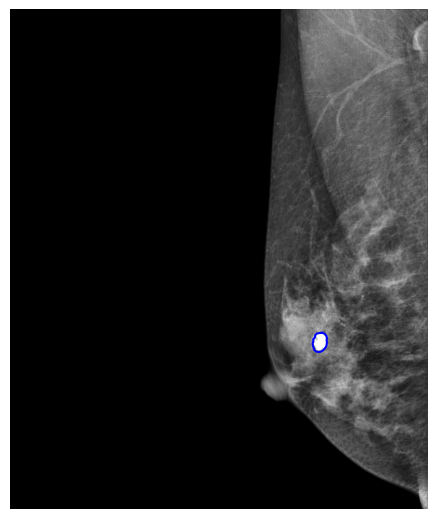

In [ ]:
patient = sorted_meta[sorted_meta["PatientID"] == "D1-0038"]
series_id = list(patient["SeriesInstanceUID"])[0]
dicom_path = f"tciaDownload/{series_id}/1-2.dcm"
json_path = f"TOMPEI-CMMD_v01_20250123/D1-0038_MLO_R_AnnotationFile.json"

overlay_masks(dicom_path, json_path)

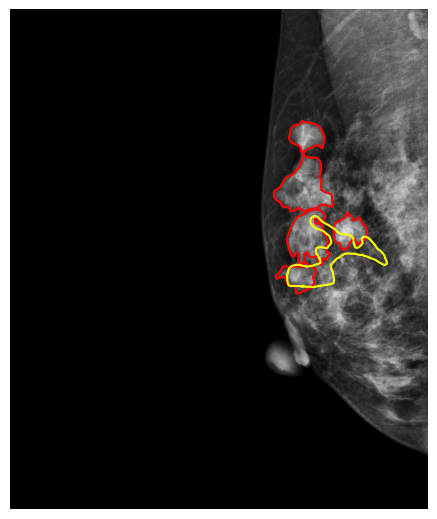

In [ ]:
patient = sorted_meta[sorted_meta["PatientID"] == "D2-0135"]
series_id = list(patient["SeriesInstanceUID"])[0]
dicom_path = f"tciaDownload/{series_id}/1-4.dcm"
json_path = f"TOMPEI-CMMD_v01_20250123/D2-0135_MLO_R_AnnotationFile.json"

overlay_masks(dicom_path, json_path)

In [ ]:
#check width and height distribution of ROI based on annotation
import json
import numpy as np

json_folder = "TOMPEI-CMMD_v01_20250123"

widths = []
heights = []

for json_file in glob(f"{json_folder}/*.json"):
    with open(json_file) as f:
        data = json.load(f)

    for roi in data:
        points = np.array([[p["x"], p["y"]] for p in roi["cgPoints"]])
        x_min, x_max = points[:,0].min(), points[:,0].max()
        y_min, y_max = points[:,1].min(), points[:,1].max()
        widths.append(x_max - x_min)
        heights.append(y_max - y_min)

widths = np.array(widths)
heights = np.array(heights)

print("Width: min={}, max={}, median={}, mean={}".format(
    widths.min(), widths.max(), np.median(widths), widths.mean()
))
print("Height: min={}, max={}, median={}, mean={}".format(
    heights.min(), heights.max(), np.median(heights), heights.mean()
))

width_75 = np.percentile(widths, 75)
height_75 = np.percentile(heights, 75)
roi_size = int(max(width_75, height_75) * 1.2)
print("Suggested ROI size (pixels):", roi_size)

Width: min=21.022167933283527, max=1072.3974248640448, median=261.1874889183855, mean=292.86306499451047
Height: min=27.208045280842725, max=1344.0954859524552, median=275.0, mean=326.70043196269665
Suggested ROI size (pixels): 491


In [ ]:
CROP_SIZE = 512

In [ ]:
#generate 512*512 ROI crops of images based on json annotation
import pydicom
import cv2

series_id_list = sorted_meta["SeriesInstanceUID"].values.tolist()
patient_id_list = sorted_meta["PatientID"].values.tolist()

# Collect all JSON paths
paths_json = sorted(glob("TOMPEI-CMMD_v01_20250123/*.json"))

# Create output directory
os.makedirs("roi", exist_ok=True)
patients_without_annotation = []

for i in tqdm(range(len(series_id_list))):
    series_id = series_id_list[i]
    patient_id = patient_id_list[i]
    paths_dicom = sorted(glob(f"tciaDownload/{series_id}/*.dcm"))
    #loop through images for each patient
    for path_dicom in paths_dicom:
        annotation_files_for_patient = [p for p in paths_json if patient_id in p]
        #check there is annotation for patient
        if annotation_files_for_patient:
            image = pydicom.dcmread(path_dicom)
            image = image.pixel_array.astype(np.float32)
            # Normalize to 0-1
            image = (image - image.min()) / (image.max() - image.min())
            image = (image * 255).astype(np.uint8)
            view, laterality = get_view_laterality(path_dicom)
            #check there is annotation for view and laterality
            annotation_file_name = "TOMPEI-CMMD_v01_20250123/" + patient_id + "_" + view + "_" + laterality + "_AnnotationFile.json"
            if annotation_file_name in annotation_files_for_patient:
                with open(annotation_file_name) as f:
                    file = json.load(f)
                    for i, roi in enumerate(file):
                        label = roi["label"].strip()
                        points = np.array([[p["x"], p["y"]] for p in roi["cgPoints"]], dtype=np.int32)

                        # Compute centroid
                        cx = int(np.mean(points[:,0]))
                        cy = int(np.mean(points[:,1]))

                        # Compute crop coordinates
                        half = CROP_SIZE // 2
                        x_min = max(cx - half, 0)
                        y_min = max(cy - half, 0)
                        x_max = x_min + CROP_SIZE
                        y_max = y_min + CROP_SIZE

                        # Adjust if crop goes outside image boundaries
                        if x_max > image.shape[1]:
                            x_max = image.shape[1]
                            x_min = x_max - CROP_SIZE
                        if y_max > image.shape[0]:
                            y_max = image.shape[0]
                            y_min = y_max - CROP_SIZE

                        # Crop the ROI
                        roi = image[y_min:y_max, x_min:x_max]

                        # Save cropped ROI
                        roi_name = f"roi/{patient_id}_{view}_{laterality}_{label}_{i}.png"
                        cv2.imwrite(roi_name, roi)
        else:
            if patient_id not in patients_without_annotation:
                patients_without_annotation.append(patient_id)

100%|██████████| 1775/1775 [02:48<00:00, 10.56it/s]


In [ ]:
faulty_images = []
for filename in os.listdir("roi"):
    if filename.endswith('.png'):
        image_path = os.path.join("roi", filename)
        image = cv2.imread(image_path)
        if image.max() == 0:
            faulty_images.append(filename)

In [ ]:
faulty_images

['D2-0229_MLO_R_calc_1.png',
 'D2-0642_MLO_L_mass_0.png',
 'D2-0224_MLO_R_mass_0.png',
 'D1-0999_MLO_R_mass_0.png',
 'D2-0224_MLO_R_calc_1.png',
 'D2-0229_MLO_R_mass_0.png']

In [ ]:
#get correct ROI crop for faulty images
for image in faulty_images:
    patient_id, view, laterality, _, _ = image.split('_')
    series_id = list(sorted_meta[sorted_meta["PatientID"] == patient_id]["SeriesInstanceUID"])[0]
    #paths_dicom = sorted(glob(f"tciaDownload/{series_id}/*.dcm"))
    #assume 1-2 stores L-MLO originally, and 1-4 stores R-MLO originally
    if laterality == "R":
        image_id = "1-2.dcm"
    else:
        image_id = "1-4.dcm"
    image = pydicom.dcmread(f"tciaDownload/{series_id}/{image_id}")
    image = image.pixel_array.astype(np.float32)
    # Normalize to 0-1
    image = (image - image.min()) / (image.max() - image.min())
    image = (image * 255).astype(np.uint8)

    annotation_file_name = "TOMPEI-CMMD_v01_20250123/" + patient_id + "_" + view + "_" + laterality + "_AnnotationFile.json"
    with open(annotation_file_name) as f:
        file = json.load(f)
        for i, roi in enumerate(file):
            label = roi["label"].strip()
            points = np.array([[p["x"], p["y"]] for p in roi["cgPoints"]], dtype=np.int32)

            # Compute centroid
            cx = int(np.mean(points[:,0]))
            cy = int(np.mean(points[:,1]))

            # Compute crop coordinates
            half = CROP_SIZE // 2
            x_min = max(cx - half, 0)
            y_min = max(cy - half, 0)
            x_max = x_min + CROP_SIZE
            y_max = y_min + CROP_SIZE

            # Adjust if crop goes outside image boundaries
            if x_max > image.shape[1]:
                x_max = image.shape[1]
                x_min = x_max - CROP_SIZE
            if y_max > image.shape[0]:
                y_max = image.shape[0]
                y_min = y_max - CROP_SIZE

            # Crop the ROI
            roi = image[y_min:y_max, x_min:x_max]

            # Save cropped ROI
            roi_name = f"roi/{patient_id}_{view}_{laterality}_{label}_{i}.png"
            cv2.imwrite(roi_name, roi)


In [ ]:
faulty_images = []
for filename in os.listdir("roi"):
    if filename.endswith('.png'):
        image_path = os.path.join("roi", filename)
        image = cv2.imread(image_path)
        if image.max() == 0:
            faulty_images.append(filename)

In [ ]:
faulty_images

[]

In [ ]:
import pandas as pd
all_images = [f for f in os.listdir("roi") if not f.startswith('.')]
image_details = pd.DataFrame(all_images, columns = ["filename"])
image_details[["PatientID", "View", "LeftRight", "Abnormality", "Index"]] = image_details['filename'].str.split('_', expand=True)
image_details["image_id"] = image_details["filename"]
image_details.head()

,filename,PatientID,View,LeftRight,Abnormality,Index,image_id
0,D2-0375_MLO_R_mass_0.png,D2-0375,MLO,R,mass,0.png,D2-0375_MLO_R_mass_0.png
1,D2-0063_MLO_R_calc_0.png,D2-0063,MLO,R,calc,0.png,D2-0063_MLO_R_calc_0.png
2,D2-0066_MLO_L_calc_0.png,D2-0066,MLO,L,calc,0.png,D2-0066_MLO_L_calc_0.png
3,D2-0314_MLO_R_mass_0.png,D2-0314,MLO,R,mass,0.png,D2-0314_MLO_R_mass_0.png
4,D2-0424_MLO_L_mass_0.png,D2-0424,MLO,L,mass,0.png,D2-0424_MLO_L_mass_0.png


In [ ]:
import pandas as pd
clinical = pd.read_excel("https://www.cancerimagingarchive.net/wp-content/uploads/TOMPEI-CMMD_clinical_data_v01_20250121.xlsx", sheet_name="Lesion Details Sheet", skiprows=2, header=0)
clinical = clinical[["ID1", "LeftRight", "classification"]].rename(columns={"ID1":"PatientID"})

In [ ]:
#data cleaning - below patient images mentioned to be indistinguishable in TCGA website so we will remove them
#D1-0202 (series UID ending with 31072, 1-1.dcm image) and D2-0284 (seriesUID ending with 98151, 1-1.dcm image)
#D1-0202 (series UID ending with 31072, 1-2.dcm image) and D2-0284 (seriesUID ending with 98151, 1-2.dcm image)
#D1-0202 (series UID ending with 31072, 1-3.dcm image) and D2-0284 (seriesUID ending with 98151, 1-3.dcm image)
#D1-0202 (series UID ending with 31072, 1-4.dcm image) and D2-0284 (seriesUID ending with 98151, 1-4.dcm image)
#D1-0808 (series UID ending with 62447, 1-1.dcm image) and D1-1292 (series UID ending with 65585, 1-1.dcm image)

patients_to_remove = ["D1-0202", "D2-0284", "D1-0808", "D1-1292", np.nan]
clinical = clinical[~clinical["PatientID"].isin(patients_to_remove)].reset_index(drop = True)

In [ ]:
clinical_image_details = pd.merge(clinical, image_details, how='inner', on=['PatientID', 'LeftRight'])
print(clinical_image_details.tail())
print(clinical_image_details.shape)

     PatientID LeftRight classification                  filename View  \
1765   D2-0743         R      Malignant  D2-0743_MLO_R_mass_0.png  MLO   
1766   D2-0744         L      Malignant  D2-0744_MLO_L_dist_0.png  MLO   
1767   D2-0746         R      Malignant  D2-0746_MLO_R_mass_0.png  MLO   
1768   D2-0747         R      Malignant  D2-0747_MLO_R_mass_0.png  MLO   
1769   D2-0749         L      Malignant  D2-0749_MLO_L_mass_0.png  MLO   

     Abnormality  Index                  image_id  
1765        mass  0.png  D2-0743_MLO_R_mass_0.png  
1766        dist  0.png  D2-0744_MLO_L_dist_0.png  
1767        mass  0.png  D2-0746_MLO_R_mass_0.png  
1768        mass  0.png  D2-0747_MLO_R_mass_0.png  
1769        mass  0.png  D2-0749_MLO_L_mass_0.png  
(1770, 8)


In [ ]:
clinical_image_details = clinical_image_details[~(clinical_image_details["classification"] == "Exclusion")].reset_index(drop=True)
print(clinical_image_details.tail())
print(clinical_image_details.shape)

     PatientID LeftRight classification                  filename View  \
1762   D2-0743         R      Malignant  D2-0743_MLO_R_mass_0.png  MLO   
1763   D2-0744         L      Malignant  D2-0744_MLO_L_dist_0.png  MLO   
1764   D2-0746         R      Malignant  D2-0746_MLO_R_mass_0.png  MLO   
1765   D2-0747         R      Malignant  D2-0747_MLO_R_mass_0.png  MLO   
1766   D2-0749         L      Malignant  D2-0749_MLO_L_mass_0.png  MLO   

     Abnormality  Index                  image_id  
1762        mass  0.png  D2-0743_MLO_R_mass_0.png  
1763        dist  0.png  D2-0744_MLO_L_dist_0.png  
1764        mass  0.png  D2-0746_MLO_R_mass_0.png  
1765        mass  0.png  D2-0747_MLO_R_mass_0.png  
1766        mass  0.png  D2-0749_MLO_L_mass_0.png  
(1767, 8)


Visualizations

In [ ]:
lesions = pd.read_excel(
    "https://www.cancerimagingarchive.net/wp-content/uploads/TOMPEI-CMMD_clinical_data_v01_20250121.xlsx",
    sheet_name="Imaging Diagnosis Details Sheet",
)

print(lesions.columns[:15])
lesions.head()

Index(['ID', 'LeftRight', 'Age', 'classification', 'Unnamed: 4',
       'Breast density', 'Mass', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Calcification', 'Unnamed: 13',
       'Unnamed: 14'],
      dtype='object')


,ID,LeftRight,Age,classification,Unnamed: 4,Breast density,Mass,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Mass - Additional Lesion,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Calcification - Additional Lesion,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,NaN,NaN,NaN,NaN,Exclusion reasons,NaN,Location,Shape,Margin,Density,...,Location,Shape,Margin,Density,Associated calcification,Other Associated Findings,Location,Morphology,Distribution,Clearly Benign Calcifications
1,D1-0001,R,44.0,Benign,NaN,heterogeneous dense,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,D1-0002,L,40.0,Benign,NaN,heterogeneous dense,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D1-0003,L,39.0,Benign,NaN,scattered,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,D1-0004,L,41.0,Benign,NaN,heterogeneous dense,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
new_columns = []
for col in lesions.columns:
    if "Unnamed" in str(col):
        replacement = str(lesions.iloc[0][col])
        if pd.isna(replacement) or replacement.strip() == "":
            replacement = col
        new_columns.append(replacement)
    else:
        new_columns.append(col)

lesions.columns = new_columns

lesions = lesions.drop(index=0).reset_index(drop=True)


In [ ]:
lesions.head()

,ID,LeftRight,Age,classification,Exclusion reasons,Breast density,Mass,Shape,Margin,Density,...,Mass - Additional Lesion,Shape,Margin,Density,Associated calcification,Other Associated Findings,Calcification - Additional Lesion,Morphology,Distribution,Clearly Benign Calcifications
0,D1-0001,R,44.0,Benign,NaN,heterogeneous dense,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,D1-0002,L,40.0,Benign,NaN,heterogeneous dense,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,D1-0003,L,39.0,Benign,NaN,scattered,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D1-0004,L,41.0,Benign,NaN,heterogeneous dense,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,D1-0005,R,42.0,Benign,NaN,extremely dense,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols_to_keep = [
    'ID',
    'LeftRight',
    'Age',
    'classification',
    'Breast density',
    'BI-RADS',
    'Mass',
    'Calcification',
    'Abnormality'
]

lesions = lesions.rename(columns={'BI-RADS\nCategory': 'BI-RADS'})
lesions = lesions.rename(columns={'ID': 'PatientID'})
lesions = pd.merge(
    lesions,
    clinical_image_details[['PatientID', 'LeftRight', 'Abnormality']],
    on=['PatientID', 'LeftRight'],
    how='inner'
)
lesions = lesions[[c for c in cols_to_keep if c in lesions.columns]]


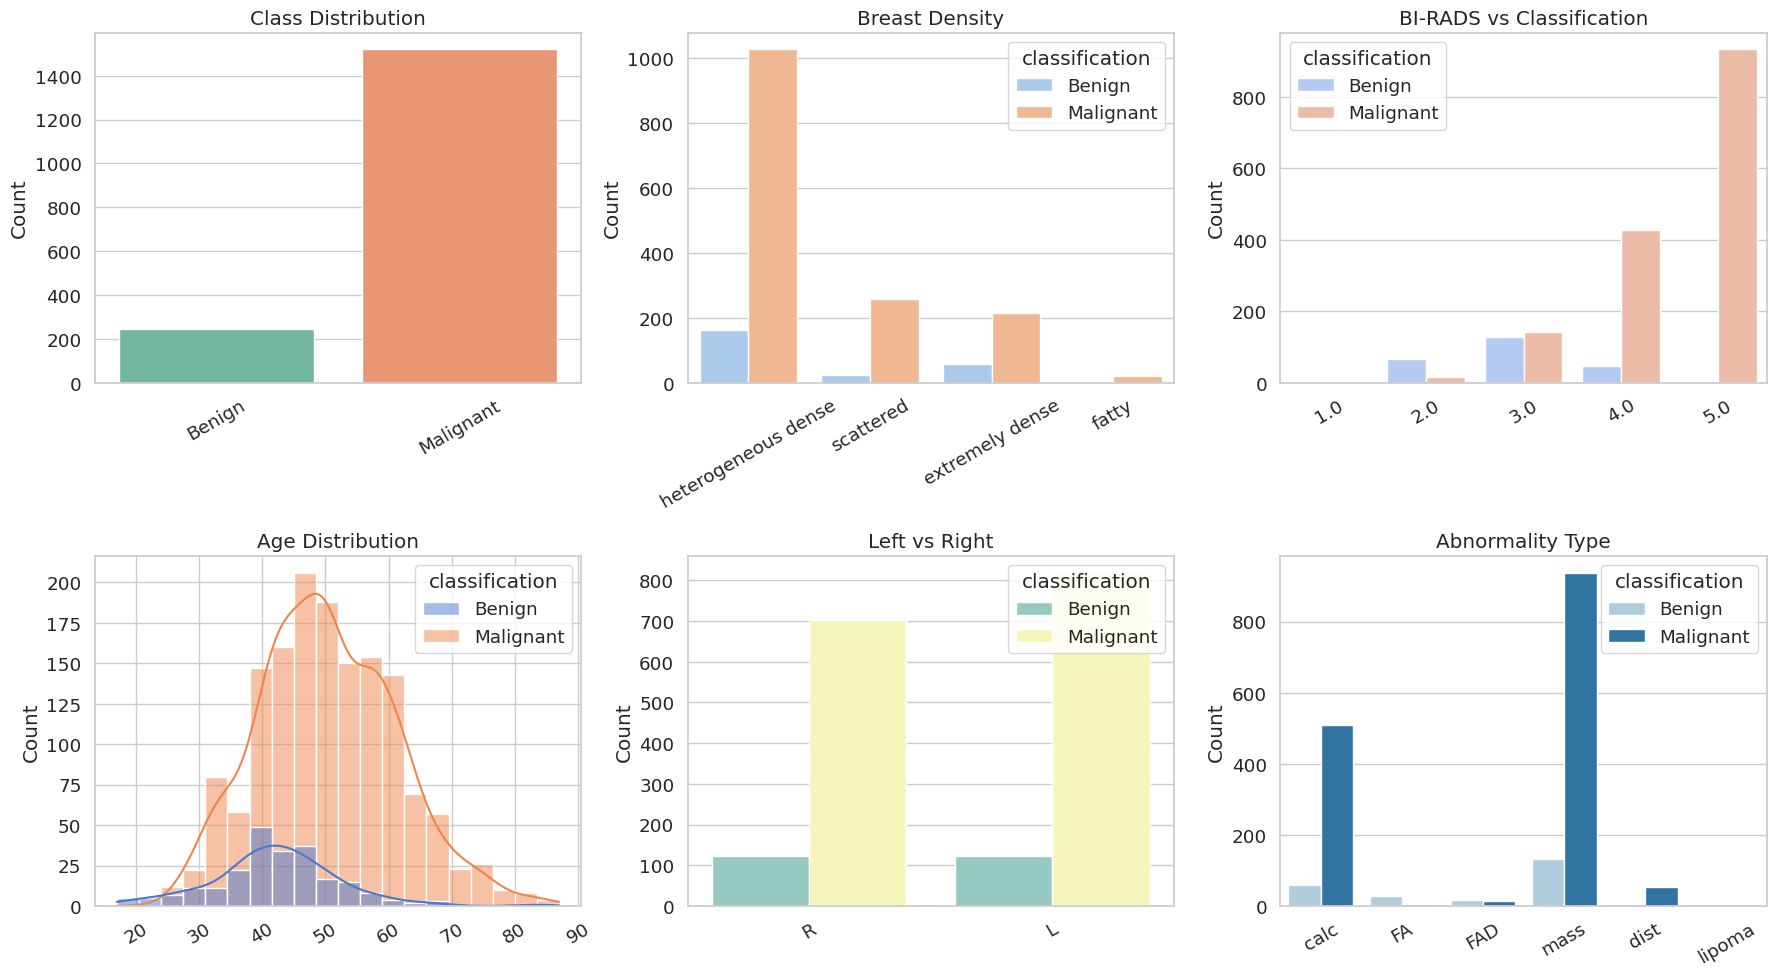

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sns.countplot(
    data=lesions,
    x='classification',
    hue='classification',
    palette='Set2',
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Class Distribution")

sns.countplot(
    data=lesions,
    x='Breast density',
    hue='classification',
    palette='pastel',
    ax=axes[1]
)
axes[1].set_title("Breast Density")

sns.countplot(
    data=lesions,
    x='BI-RADS',
    hue='classification',
    palette='coolwarm',
    ax=axes[2]
)
axes[2].set_title("BI-RADS vs Classification")

sns.histplot(
    data=lesions,
    x='Age',
    hue='classification',
    bins=20,
    kde=True,
    palette='muted',
    ax=axes[3]
)
axes[3].set_title("Age Distribution")

sns.countplot(
    data=lesions,
    x='LeftRight',
    hue='classification',
    palette='Set3',
    ax=axes[4]
)
axes[4].set_title("Left vs Right")

sns.countplot(
    data=lesions,
    x='Abnormality',
    hue='classification',
    palette='Paired',
    ax=axes[5]
)
axes[5].set_title("Abnormality Type")

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


Below, we are getting normal breast tissue without annotation and cropping random ROI to be part of benign class

In [ ]:
samples_with_annotation = set(list(clinical_image_details["PatientID"] + "_" + clinical_image_details["LeftRight"]))
clinical_samples = set(list(clinical["PatientID"] + "_" + clinical["LeftRight"]))
print(len(samples_with_annotation))
print(len(clinical_samples))

1379
2595


In [ ]:
samples_without_annotation = list(clinical_samples - samples_with_annotation)
print(len(samples_without_annotation))

1216


In [ ]:
clinical_image_details['classification'].value_counts()

,count
classification,
Malignant,1521
Benign,246


In [ ]:
clinical_image_details['Abnormality'].value_counts()

,count
Abnormality,
mass,1071
calc,568
dist,60
FA,34
FAD,33
lipoma,1


In [ ]:
clinical_no_annotations = clinical[clinical["PatientID"].isin([sample.split("_")[0] for sample in samples_without_annotation])]
clinical_no_annotations['classification'].value_counts()

,count
classification,
Normal,1051
Malignant,673
Invisible,140
Exclusion,25
Benign,20


In [ ]:
additional_benign_samples = clinical_no_annotations[clinical_no_annotations["classification"] == "Normal"].reset_index(drop=True)

In [ ]:
additional_benign_samples.shape

(1051, 3)

In [ ]:
def crop_image(image, size=512):
    gray = image if len(image.shape) == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

    ys, xs = np.where(mask > 0)

    cy = (ys.min() + ys.max()) // 2
    cx = (xs.min() + xs.max()) // 2

    half = size // 2

    return cv2.resize(
        image[
            max(cy-half, 0):cy+half,
            max(cx-half, 0):cx+half
        ],
        (size, size)
    )

In [ ]:
for i in tqdm(range(additional_benign_samples.shape[0])):
	row = additional_benign_samples.iloc[i]
	patient = row["PatientID"]
	laterality = row["LeftRight"]
	series_id = list(sorted_meta[sorted_meta["PatientID"] == patient]["SeriesInstanceUID"])[0]
	paths_dicom = sorted(glob(f"tciaDownload/{series_id}/*.dcm"))
	if len(paths_dicom) == 2:
		image_id = "1-2.dcm"
	else:
		if laterality == "L":
			image_id = "1-2.dcm"
		else:
			image_id = "1-4.dcm"
	image = pydicom.dcmread(f"tciaDownload/{series_id}/{image_id}")
	image = image.pixel_array.astype(np.float32)
	image = (image - image.min()) / (image.max() - image.min())
	image = (image * 255).astype(np.uint8)
	cropped_image = crop_image(image)
	roi_name = f"roi/{patient}_MLO_{laterality}_normal_0.png"
	cv2.imwrite(roi_name, cropped_image)

100%|██████████| 1051/1051 [01:02<00:00, 16.74it/s]


In [ ]:
faulty_images = []
for filename in os.listdir("roi"):
    if filename.endswith('.png'):
        image_path = os.path.join("roi", filename)
        image = cv2.imread(image_path)
        if image.max() == 0:
            faulty_images.append(filename)

In [ ]:
faulty_images

[]

In [ ]:
!find roi -mindepth 1 -maxdepth 1 | wc -l

2824


In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob

def show_saved_rois(folder="roi", n=8):
    files = glob.glob(f"{folder}/*.png")

    normal_files = [f for f in files if "normal" in f.lower()]

    plt.figure(figsize=(12, 6))

    for i, f in enumerate(normal_files[:n]):
        img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)

        plt.subplot(4, n//4, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(f.split("/")[-1], fontsize=7)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

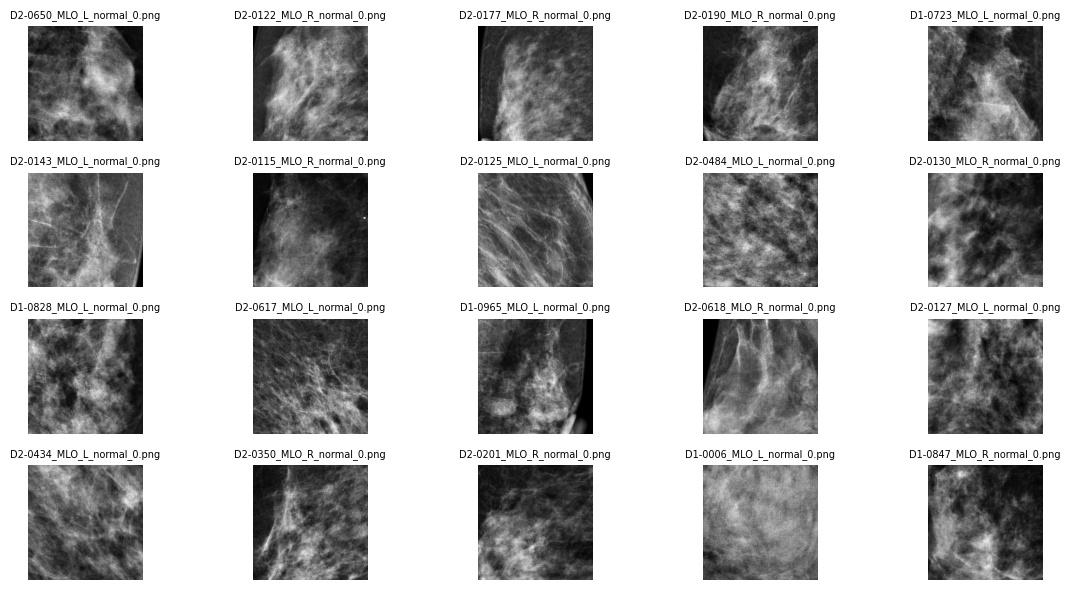

In [ ]:
show_saved_rois("roi", n=20)

In [ ]:
all_images = [f for f in os.listdir("roi") if not f.startswith('.')]
image_details = pd.DataFrame(all_images, columns = ["filename"])
image_details[["PatientID", "View", "LeftRight", "Abnormality", "Index"]] = image_details['filename'].str.split('_', expand=True)
image_details["image_id"] = image_details["filename"]
image_details.head()

,filename,PatientID,View,LeftRight,Abnormality,Index,image_id
0,D2-0375_MLO_R_mass_0.png,D2-0375,MLO,R,mass,0.png,D2-0375_MLO_R_mass_0.png
1,D2-0650_MLO_L_normal_0.png,D2-0650,MLO,L,normal,0.png,D2-0650_MLO_L_normal_0.png
2,D2-0063_MLO_R_calc_0.png,D2-0063,MLO,R,calc,0.png,D2-0063_MLO_R_calc_0.png
3,D2-0066_MLO_L_calc_0.png,D2-0066,MLO,L,calc,0.png,D2-0066_MLO_L_calc_0.png
4,D2-0122_MLO_R_normal_0.png,D2-0122,MLO,R,normal,0.png,D2-0122_MLO_R_normal_0.png


In [ ]:
image_details = image_details[image_details["Abnormality"].isin(["mass", "calc", "normal"])]

In [ ]:
clinical_image_details = pd.merge(clinical, image_details, how='inner', on=['PatientID', 'LeftRight'])
print(clinical_image_details.tail())
print(clinical_image_details.shape)

     PatientID LeftRight classification                    filename View  \
2688   D2-0747         L         Normal  D2-0747_MLO_L_normal_0.png  MLO   
2689   D2-0747         R      Malignant    D2-0747_MLO_R_mass_0.png  MLO   
2690   D2-0748         L         Normal  D2-0748_MLO_L_normal_0.png  MLO   
2691   D2-0749         L      Malignant    D2-0749_MLO_L_mass_0.png  MLO   
2692   D2-0749         R         Normal  D2-0749_MLO_R_normal_0.png  MLO   

     Abnormality  Index                    image_id  
2688      normal  0.png  D2-0747_MLO_L_normal_0.png  
2689        mass  0.png    D2-0747_MLO_R_mass_0.png  
2690      normal  0.png  D2-0748_MLO_L_normal_0.png  
2691        mass  0.png    D2-0749_MLO_L_mass_0.png  
2692      normal  0.png  D2-0749_MLO_R_normal_0.png  
(2693, 8)


In [ ]:
clinical_image_details = clinical_image_details[~(clinical_image_details["classification"] == "Exclusion")].reset_index(drop=True)
print(clinical_image_details.tail())
print(clinical_image_details.shape)

     PatientID LeftRight classification                    filename View  \
2685   D2-0747         L         Normal  D2-0747_MLO_L_normal_0.png  MLO   
2686   D2-0747         R      Malignant    D2-0747_MLO_R_mass_0.png  MLO   
2687   D2-0748         L         Normal  D2-0748_MLO_L_normal_0.png  MLO   
2688   D2-0749         L      Malignant    D2-0749_MLO_L_mass_0.png  MLO   
2689   D2-0749         R         Normal  D2-0749_MLO_R_normal_0.png  MLO   

     Abnormality  Index                    image_id  
2685      normal  0.png  D2-0747_MLO_L_normal_0.png  
2686        mass  0.png    D2-0747_MLO_R_mass_0.png  
2687      normal  0.png  D2-0748_MLO_L_normal_0.png  
2688        mass  0.png    D2-0749_MLO_L_mass_0.png  
2689      normal  0.png  D2-0749_MLO_R_normal_0.png  
(2690, 8)


In [ ]:
print(clinical_image_details["classification"].isna().sum()) #check no missing labels
clinical_image_details.loc[:, "label"] = 0
clinical_image_details.loc[clinical_image_details["classification"] == "Malignant", "label"] = 1
print(clinical_image_details.tail())
print(clinical_image_details.shape)

0
     PatientID LeftRight classification                    filename View  \
2685   D2-0747         L         Normal  D2-0747_MLO_L_normal_0.png  MLO   
2686   D2-0747         R      Malignant    D2-0747_MLO_R_mass_0.png  MLO   
2687   D2-0748         L         Normal  D2-0748_MLO_L_normal_0.png  MLO   
2688   D2-0749         L      Malignant    D2-0749_MLO_L_mass_0.png  MLO   
2689   D2-0749         R         Normal  D2-0749_MLO_R_normal_0.png  MLO   

     Abnormality  Index                    image_id  label  
2685      normal  0.png  D2-0747_MLO_L_normal_0.png      0  
2686        mass  0.png    D2-0747_MLO_R_mass_0.png      1  
2687      normal  0.png  D2-0748_MLO_L_normal_0.png      0  
2688        mass  0.png    D2-0749_MLO_L_mass_0.png      1  
2689      normal  0.png  D2-0749_MLO_R_normal_0.png      0  
(2690, 9)


In [ ]:
print(clinical_image_details["label"].isna().sum()) #check no missing labels

0


In [ ]:
!pip install torch torchvision torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.6 MB/s eta 0:00:00


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

import torch
from torch.utils.data import Dataset
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f"{self.img_dir}/{row.image_id}"
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row.label, dtype=torch.long)
        return image, label

In [ ]:
import random

SEED = 23
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
clinical_image_details.head()

,PatientID,LeftRight,classification,filename,View,Abnormality,Index,image_id,label
0,D1-0001,R,Benign,D1-0001_MLO_R_calc_0.png,MLO,calc,0.png,D1-0001_MLO_R_calc_0.png,0
1,D1-0002,L,Benign,D1-0002_MLO_L_calc_0.png,MLO,calc,0.png,D1-0002_MLO_L_calc_0.png,0
2,D1-0003,L,Benign,D1-0003_MLO_L_calc_0.png,MLO,calc,0.png,D1-0003_MLO_L_calc_0.png,0
3,D1-0004,L,Benign,D1-0004_MLO_L_calc_0.png,MLO,calc,0.png,D1-0004_MLO_L_calc_0.png,0
4,D1-0005,R,Benign,D1-0005_MLO_R_calc_0.png,MLO,calc,0.png,D1-0005_MLO_R_calc_0.png,0


In [ ]:
clinical_image_details["Index"] = clinical_image_details["Index"].str.split(".").str[0].astype(int)

In [ ]:
clinical_image_details.head()

,PatientID,LeftRight,classification,filename,View,Abnormality,Index,image_id,label
0,D1-0001,R,Benign,D1-0001_MLO_R_calc_0.png,MLO,calc,0,D1-0001_MLO_R_calc_0.png,0
1,D1-0002,L,Benign,D1-0002_MLO_L_calc_0.png,MLO,calc,0,D1-0002_MLO_L_calc_0.png,0
2,D1-0003,L,Benign,D1-0003_MLO_L_calc_0.png,MLO,calc,0,D1-0003_MLO_L_calc_0.png,0
3,D1-0004,L,Benign,D1-0004_MLO_L_calc_0.png,MLO,calc,0,D1-0004_MLO_L_calc_0.png,0
4,D1-0005,R,Benign,D1-0005_MLO_R_calc_0.png,MLO,calc,0,D1-0005_MLO_R_calc_0.png,0


In [ ]:
clinical_image_details.loc[:, "label"] = 0
clinical_image_details.loc[clinical_image_details["classification"] == "Malignant", "label"] = 1
clinical_image_details.loc[clinical_image_details["classification"] == "Normal", "label"] = 2
print(clinical_image_details.tail())
print(clinical_image_details.shape)

     PatientID LeftRight classification                    filename View  \
2685   D2-0747         L         Normal  D2-0747_MLO_L_normal_0.png  MLO   
2686   D2-0747         R      Malignant    D2-0747_MLO_R_mass_0.png  MLO   
2687   D2-0748         L         Normal  D2-0748_MLO_L_normal_0.png  MLO   
2688   D2-0749         L      Malignant    D2-0749_MLO_L_mass_0.png  MLO   
2689   D2-0749         R         Normal  D2-0749_MLO_R_normal_0.png  MLO   

     Abnormality  Index                    image_id  label  
2685      normal      0  D2-0747_MLO_L_normal_0.png      2  
2686        mass      0    D2-0747_MLO_R_mass_0.png      1  
2687      normal      0  D2-0748_MLO_L_normal_0.png      2  
2688        mass      0    D2-0749_MLO_L_mass_0.png      1  
2689      normal      0  D2-0749_MLO_R_normal_0.png      2  
(2690, 9)


In [ ]:
lesion_mapping = {
    'mass': 0,
    'calc': 1,
    'normal': 0  # Masked out in the training loop, safe to set as 0
}

In [ ]:
clinical_image_details['les'] = clinical_image_details['Abnormality'].map(lesion_mapping)
clinical_image_details['abn'] = clinical_image_details['Abnormality'].apply(lambda x: 0 if x == 'normal' else 1)

In [ ]:
clinical_image_details.head()

,PatientID,LeftRight,classification,filename,View,Abnormality,Index,image_id,label,les,abn
0,D1-0001,R,Benign,D1-0001_MLO_R_calc_0.png,MLO,calc,0,D1-0001_MLO_R_calc_0.png,0,1,1
1,D1-0002,L,Benign,D1-0002_MLO_L_calc_0.png,MLO,calc,0,D1-0002_MLO_L_calc_0.png,0,1,1
2,D1-0003,L,Benign,D1-0003_MLO_L_calc_0.png,MLO,calc,0,D1-0003_MLO_L_calc_0.png,0,1,1
3,D1-0004,L,Benign,D1-0004_MLO_L_calc_0.png,MLO,calc,0,D1-0004_MLO_L_calc_0.png,0,1,1
4,D1-0005,R,Benign,D1-0005_MLO_R_calc_0.png,MLO,calc,0,D1-0005_MLO_R_calc_0.png,0,1,1


In [ ]:
#split the patients so that for cropped ROIs from the same patient, they will not straddle train / val / test

import pandas as pd
from sklearn.model_selection import train_test_split

df = clinical_image_details[["PatientID", "image_id", "label"]]

# One row per patient
patients = (
df.groupby("PatientID")["label"]
.max()
.reset_index()
)

train_patients, val_test_patients = train_test_split(
patients,
test_size=0.2,
random_state=23,
stratify=patients["label"]
)

val_patients, test_patients = train_test_split(
val_test_patients,
test_size=0.5,
random_state=23,
stratify=val_test_patients["label"]
)

In [ ]:
train_df = df[df["PatientID"].isin(train_patients["PatientID"])].reset_index(drop=True)
val_df   = df[df["PatientID"].isin(val_patients["PatientID"])].reset_index(drop=True)
test_df  = df[df["PatientID"].isin(test_patients["PatientID"])].reset_index(drop=True)

In [ ]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2150, 5)
(267, 5)
(273, 5)


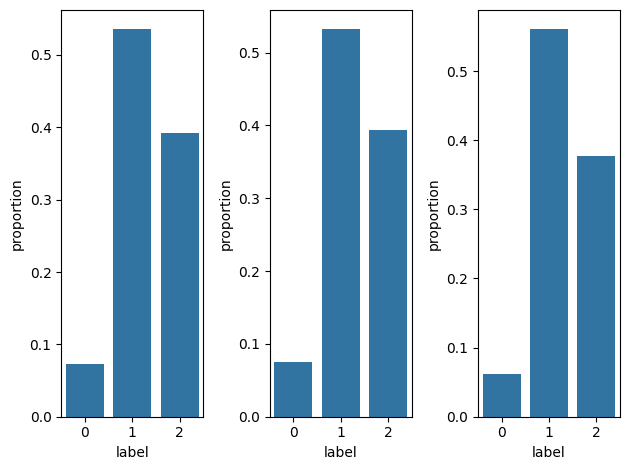

In [ ]:
#inspect class balance
import seaborn as sns
import matplotlib.pyplot as plt

plt.subplot(1, 3, 1)
sns.barplot(train_df["label"].value_counts(normalize=True))
plt.subplot(1, 3, 2)
sns.barplot(val_df["label"].value_counts(normalize=True))
plt.subplot(1, 3, 3)
sns.barplot(test_df["label"].value_counts(normalize=True))
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.ToTensor()
])

train_ds = CustomImageDataset(
    train_df,
    img_dir="roi",
    transform=transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

def get_stats(loader):
    total_sum = 0.0
    total_squared_sum = 0.0
    total_pixels = 0

    for images, _ in loader:

        # images shape:
        # [B, 1, H, W] for grayscale
        images = images.float()

        total_sum += images.sum()
        total_squared_sum += (images ** 2).sum()

        total_pixels += images.numel()

    mean = total_sum / total_pixels

    std = torch.sqrt(
        (total_squared_sum / total_pixels) - (mean ** 2)
    )

    return mean.item(), std.item()

TRAIN_MEAN, TRAIN_STD = get_stats(train_loader)

print("Dataset mean:", TRAIN_MEAN)
print("Dataset std :", TRAIN_STD)

Dataset mean: 0.33799079060554504
Dataset std : 0.1913602501153946


In [ ]:
light_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    ),

    transforms.Normalize(
        mean=[TRAIN_MEAN],
        std=[TRAIN_STD]
    )
])

strong_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
    ),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),

    transforms.Normalize(
        mean=[TRAIN_MEAN],
        std=[TRAIN_STD]
    )
])

In [ ]:
class CustomImageDatasetWithAugmentation(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, transform_light, transform_strong):
        self.df = df
        self.img_dir = img_dir
        self.transform_light = transform_light
        self.transform_strong = transform_strong

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(f"{self.img_dir}/{row.image_id}", 0)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        label = int(row['label'])

        if label == 0:
            img = self.transform_strong(img)
        else:
            img = self.transform_light(img)

        return img, label

    def __len__(self):
        return len(self.df)

In [ ]:
train_ds_normalised = CustomImageDatasetWithAugmentation(train_df, img_dir="roi", transform_light=light_transform, transform_strong=strong_transform)
val_ds_normalised   = CustomImageDatasetWithAugmentation(val_df, img_dir="roi", transform_light=light_transform, transform_strong=strong_transform)
test_ds_normalised  = CustomImageDatasetWithAugmentation(test_df, img_dir="roi", transform_light=light_transform, transform_strong=strong_transform)

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def unnormalize(img, mean, std):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    img = img * std + mean
    return img


def inspect_dataset(dataset, idx=0, n=6, mean=None, std=None):
    plt.figure(figsize=(12,6))

    for i in range(n):
        img, label = dataset[idx]  # stochastic augmentation

        # 🔧 undo normalization for visualization
        if mean is not None and std is not None:
            img = unnormalize(img, mean, std)

        # CHW → HWC
        img = img.permute(1,2,0).cpu().numpy()

        # keep display-safe range
        img = np.clip(img, 0, 1)

        plt.subplot(2, n//2, i+1)
        plt.imshow(img.squeeze(), cmap="gray")
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

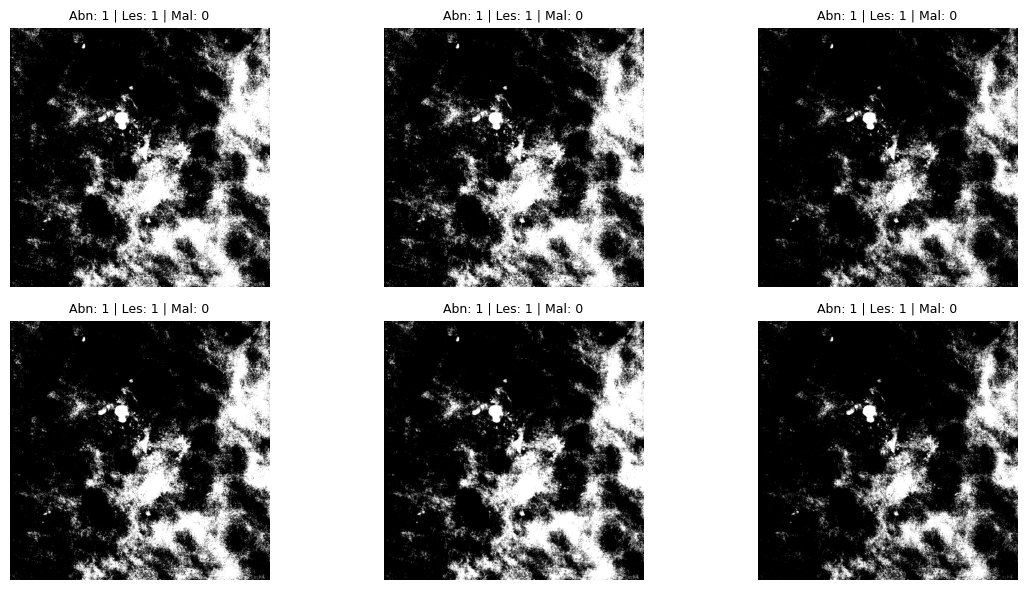

In [ ]:
inspect_dataset(train_ds_normalised, idx=2)

In [ ]:
import numpy as np
from torch.utils.data import WeightedRandomSampler

labels = train_df["label"].values

class_counts = np.bincount(labels)

In [ ]:
class_weights = 1. / class_counts
sample_weights = class_weights[labels]
g = torch.Generator()
g.manual_seed(23)

In [ ]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator = g
)

In [ ]:
#train_loader = DataLoader(train_ds_normalised, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False)
train_loader = DataLoader(train_ds_normalised, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds_normalised,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds_normalised,  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
image, label = next(iter(train_loader))

In [ ]:
image.shape

torch.Size([32, 3, 512, 512])

In [ ]:
label.shape

torch.Size([32])

In [ ]:
from collections import Counter

labels_list = label.cpu().tolist()
counts = Counter(labels_list)

print("Batch label counts:", counts)

Batch label counts: Counter({2: 15, 1: 13, 0: 4})


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Select device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Hyperparameters
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

all_labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

In [ ]:
#make aggresiveness of class weights tunable

class_weights = torch.tensor([
    2.0,   # benign
    1.0,   # malignant
    1.0    # normal
], dtype=torch.float32).to(DEVICE)

# Transfer Learning - ResNet18



In [ ]:
#transfer learning
import torch.nn as nn
import torchvision.models as models

num_classes = 3

# Load ResNet18 model
model = models.resnet18(weights="IMAGENET1K_V1") # load V1 weights for reproducibility

# Freeze backbone
for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


In [ ]:
import torch.optim as optim
from torchmetrics.classification import Accuracy, F1Score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
#optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Set up metrics
train_metric =  F1Score(task="multiclass", num_classes=num_classes, average="macro").to(DEVICE)
val_metric = F1Score(task="multiclass", num_classes=num_classes, average="macro").to(DEVICE)

per_class_metric = F1Score(
    task="multiclass",
    num_classes=num_classes,
    average=None
).to(DEVICE)

# Set up scheduler
#scheduler = ReduceLROnPlateau(optimizer)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

CHECKPOINT_FILE = "checkpoint_resnet.pt"

In [ ]:
model = model.to(DEVICE)

In [ ]:
from tqdm import tqdm

# Set-up reporting interval
REPORT_INTERVAL = 5

# Set-up checkpointing and early stopping
best_val_metric = 0.0
no_improve_count = 0
patience = 10
min_delta = 1e-4

# Set-up tracking of loss/metric per epoch
running_train_loss = []
running_train_metric = []
running_val_loss = []
running_val_metric = []

# Epoch loop
for epoch in range(NUM_EPOCHS):

    # ---- Training ----
    model.train()

    train_loss_sum = 0.0
    train_metric.reset()

    for xb, yb in tqdm(train_loader):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        # Forward + loss
        output = model(xb)
        loss = criterion(output, yb)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Accumulate training loss + metric
        train_loss_sum += loss.item() * xb.size(0)
        train_metric.update(output, yb)

    # Calculate average training loss/metric for epoch
    avg_train_loss = train_loss_sum / len(train_loader.dataset)
    avg_train_metric = train_metric.compute().item()

    # Track training loss/metric per epoch
    running_train_loss.append(avg_train_loss)
    running_train_metric.append(avg_train_metric)

    # ---- Validation ----
    model.eval()
    val_loss_sum = 0.0
    val_metric.reset()
    per_class_metric.reset()

    with torch.no_grad():
        for xb, yb in tqdm(val_loader):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            output = model(xb)
            loss = criterion(output, yb)
            val_loss_sum += loss.item() * xb.size(0)
            val_metric.update(output, yb)
            per_class_metric.update(output, yb)

    # Calculate average validation loss/metric for epoch
    avg_val_loss = val_loss_sum / len(val_loader.dataset)
    avg_val_metric = val_metric.compute().item()

    class_f1 = per_class_metric.compute().cpu().numpy()

    benign_f1 = class_f1[0]
    malignant_f1 = class_f1[1]
    normal_f1 = class_f1[2]

    # Track validation loss/metric per epoch
    running_val_loss.append(avg_val_loss)
    running_val_metric.append(avg_val_metric)

    # ---- Scheduler step (after validation) ----
    scheduler.step(avg_val_metric)

    # ---- Checkpointing + Early Stopping ----
    if avg_val_metric > best_val_metric + min_delta:
        best_val_metric = avg_val_metric
        no_improve_count = 0

        # Save checkpoint
        torch.save(
            {
                "epoch": epoch,
                "best_val_metric": best_val_metric,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
            },
            CHECKPOINT_FILE
        )
        print(
            f"Epoch {epoch+1}: "
            f"Saved new best model "
            f"(Macro-F1={best_val_metric:.4f})"
        )
    else:
        no_improve_count += 1
        print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{patience})")

        if no_improve_count >= patience:
            print(f"Epoch {epoch+1}: Early stopping triggered.")
            break

    # ---- Report ----
    if (epoch + 1) == 1 or (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == NUM_EPOCHS:
        print(
            f"Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Loss {avg_train_loss:.4f} | "
            f"Train Macro-F1 {avg_train_metric:.3f} | "
            f"Val Loss {avg_val_loss:.4f} | "
            f"Val Macro-F1 {avg_val_metric:.3f} | "
            f"Benign F1 {benign_f1:.3f} | "
            f"Malignant F1 {malignant_f1:.3f} | "
            f"Normal F1 {normal_f1:.3f}"
        )

100%|██████████| 9/9 [00:05<00:00,  1.74it/s]


Epoch 1: Saved new best model (Macro-F1=0.4357)
Epoch 1/30 | Train Loss 0.8839 | Train Macro-F1 0.446 | Val Loss 0.8434 | Val Macro-F1 0.436 | Benign F1 0.000 | Malignant F1 0.743 | Normal F1 0.564


100%|██████████| 9/9 [00:05<00:00,  1.75it/s]


Epoch 2: Saved new best model (Macro-F1=0.4693)


100%|██████████| 9/9 [00:05<00:00,  1.62it/s]


...

Epoch 28: No improvement (2/10)


100%|██████████| 9/9 [00:05<00:00,  1.60it/s]


Epoch 29: No improvement (3/10)


100%|██████████| 9/9 [00:05<00:00,  1.74it/s]

Epoch 30: No improvement (4/10)
Epoch 30/30 | Train Loss 0.7007 | Train Macro-F1 0.588 | Val Loss 0.6950 | Val Macro-F1 0.564 | Benign F1 0.143 | Malignant F1 0.789 | Normal F1 0.760


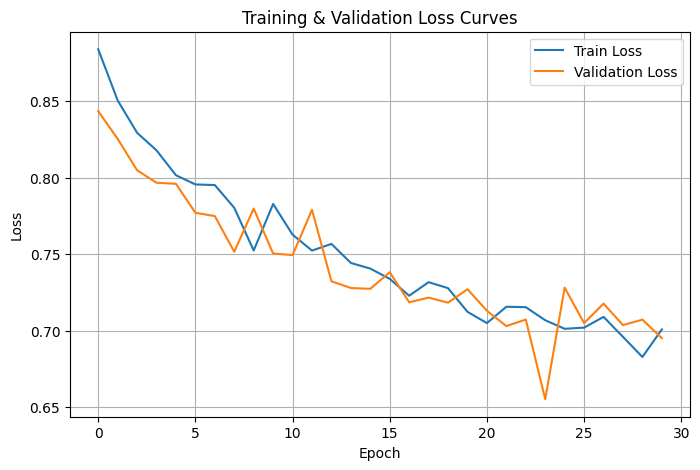

In [ ]:
import matplotlib.pyplot as plt

# Visualization loss curve
plt.figure(figsize=(8,5))
plt.plot(running_train_loss, label='Train Loss')
plt.plot(running_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

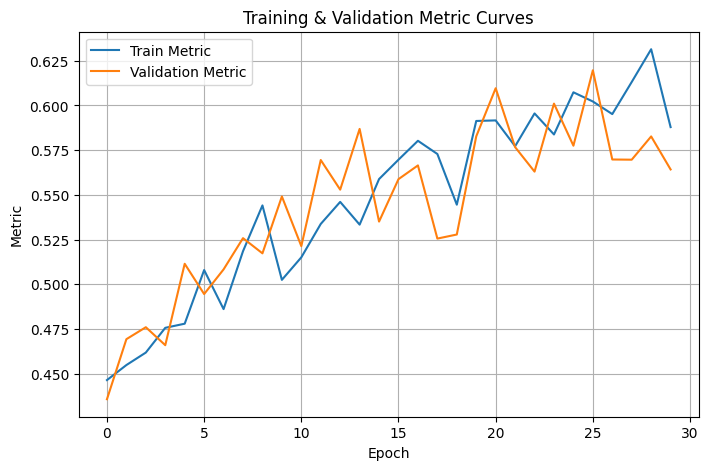

In [ ]:
# Visualization metric curves
plt.figure(figsize=(8,5))
plt.plot(running_train_metric, label='Train Metric')
plt.plot(running_val_metric, label='Validation Metric')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Training & Validation Metric Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Restore best model for evaluation
checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])

# Set up test metric
test_metric = F1Score(task="multiclass", num_classes=num_classes, average="macro").to(DEVICE)

# Initialize loss/metric
test_loss_sum = 0.0
test_metric.reset()

# Evaluate on test set
model.eval()

with torch.no_grad():
    for xb, yb in tqdm(test_loader):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        output = model(xb)
        loss = criterion(output, yb)

        test_loss_sum += loss.item()
        test_metric.update(output, yb)

avg_test_loss = test_loss_sum / max(1, len(test_loader))
test_metric_value = test_metric.compute().item()

print(f"Test loss: {avg_test_loss:.4f} | Accuracy: {test_metric_value:.3f}")

100%|██████████| 9/9 [00:04<00:00,  1.81it/s]

Test loss: 0.7081 | Accuracy: 0.555


In [ ]:
import torch.nn.functional as F

# Generate predictions on test set
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        output = model(xb)                   # logits
        preds = output.argmax(dim=1)         # predicted class
        probs = F.softmax(output, dim=1)  # probability of class 1

        # Collect labels and predictions
        all_labels.extend(yb.cpu().numpy())     # move to CPU and change to numpy
        all_preds.extend(preds.cpu().numpy())   # move to CPU and change to numpy
        all_probs.extend(probs.cpu().numpy())

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

num_classes = 3

y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
roc_auc["macro"] = auc(all_fpr, mean_tpr)

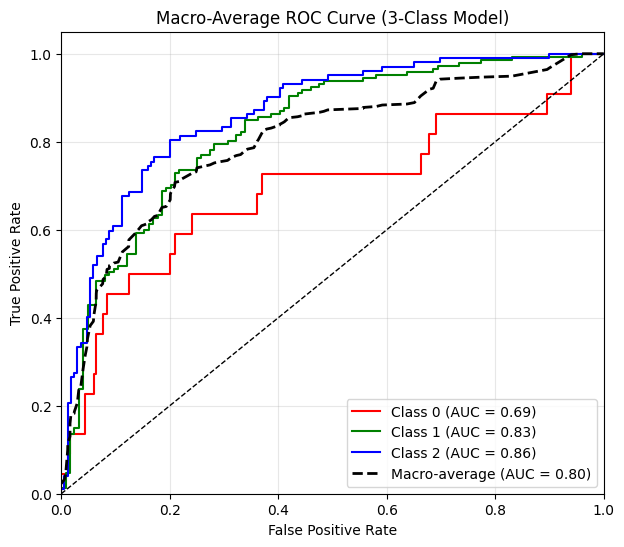

In [ ]:
plt.figure(figsize=(7, 6))

# Plot per-class ROC curves
colors = ["red", "green", "blue"]
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5,
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

# Plot macro-average ROC
plt.plot(all_fpr, mean_tpr, color="black", lw=2, linestyle="--",
         label=f"Macro-average (AUC = {roc_auc['macro']:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve (3-Class Model)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

<Figure size 2000x2000 with 0 Axes>

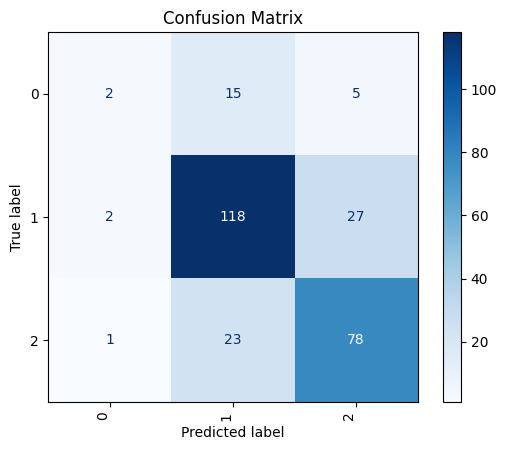

              precision    recall  f1-score   support

           0       0.40      0.09      0.15        22
           1       0.76      0.80      0.78       147
           2       0.71      0.76      0.74       102

    accuracy                           0.73       271
   macro avg       0.62      0.55      0.55       271
weighted avg       0.71      0.73      0.71       271



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Create a confusion matrix
cm = confusion_matrix(all_labels, all_preds)
# Plot confusion matrix
plt.figure(figsize=(20,20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks(rotation=90, ha="right")
plt.grid(False)
plt.show()

print(classification_report(all_labels, all_preds))

# Multi Head Resnet18
Instead of the independent gated network and expert classifiers proposed by Konaka et. al., a cascaded hierarchical model is explored to mimic medical reasoning. This model allows prior steps to influence the output of latter ones.

In [ ]:
!pip install torchinfo

In [ ]:
#split the patients so that for cropped ROIs from the same patient, they will not straddle train / val / test

import pandas as pd
from sklearn.model_selection import train_test_split

df = clinical_image_details[["PatientID", "image_id", "label", "les", "abn"]]

# One row per patient
patients = (
    df.groupby("PatientID")[["label", "les", "abn"]]
    .max()
    .reset_index()
)

patients["strat_key"] = patients["label"].astype(str) + "_" + patients["les"].astype(str)

train_p_ids, val_test_p_ids = train_test_split(
    patients,
    test_size=0.2,
    random_state=23,
    stratify=patients["strat_key"]
)

val_p_ids, test_p_ids = train_test_split(
    val_test_p_ids,
    test_size=0.5,
    random_state=23,
    stratify=val_test_p_ids["strat_key"]
)

In [ ]:
train_df = df[df["PatientID"].isin(train_p_ids["PatientID"])].reset_index(drop=True)
val_df   = df[df["PatientID"].isin(val_p_ids["PatientID"])].reset_index(drop=True)
test_df  = df[df["PatientID"].isin(test_p_ids["PatientID"])].reset_index(drop=True)

In [ ]:
class CustomImageDatasetWithAugmentation(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, transform_light, transform_strong):
        self.df = df
        self.img_dir = img_dir
        self.transform_light = transform_light
        self.transform_strong = transform_strong

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(f"{self.img_dir}/{row.image_id}", 0)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        mal_label = int(row['label'])          # 0: Benign, 1: Malignant, 2: Normal
        les_label = int(row['les'])    # 0: Mass, 1: Calc, 0: No lesion
        abn_label = int(row['abn'])    # 0: Normal, 1: Abnormal

        if mal_label == 0:
            img = self.transform_strong(img)
        else:
            img = self.transform_light(img)

        targets = {
            'abn': torch.tensor(abn_label, dtype=torch.long),
            'les': torch.tensor(les_label, dtype=torch.long),
            'mal': torch.tensor(mal_label, dtype=torch.long)
        }

        return img, targets

    def __len__(self):
        return len(self.df)

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def unnormalize(img, mean, std):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    img = img * std + mean
    return img


def inspect_dataset(dataset, idx=0, n=6, mean=None, std=None):
    plt.figure(figsize=(12,6))

    for i in range(n):
        img, targets = dataset[idx]  # stochastic augmentation

        # 🔧 undo normalization for visualization
        if mean is not None and std is not None:
            img = unnormalize(img, mean, std)

        # CHW → HWC
        img = img.permute(1,2,0).cpu().numpy()

        # keep display-safe range
        img = np.clip(img, 0, 1)

        plt.subplot(2, n//2, i+1)
        plt.imshow(img.squeeze(), cmap="gray")
        # 2. Extract specific values for a clean multi-line or compact string
        abn = targets['abn'].item()
        les = targets['les'].item()
        mal = targets['mal'].item()

        # 3. Create a clean string layout
        title_text = f"Abn: {abn} | Les: {les} | Mal: {mal}"

        # 4. Set font size directly here (e.g., 'small', 'x-small', or a number like 9)
        plt.title(title_text, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

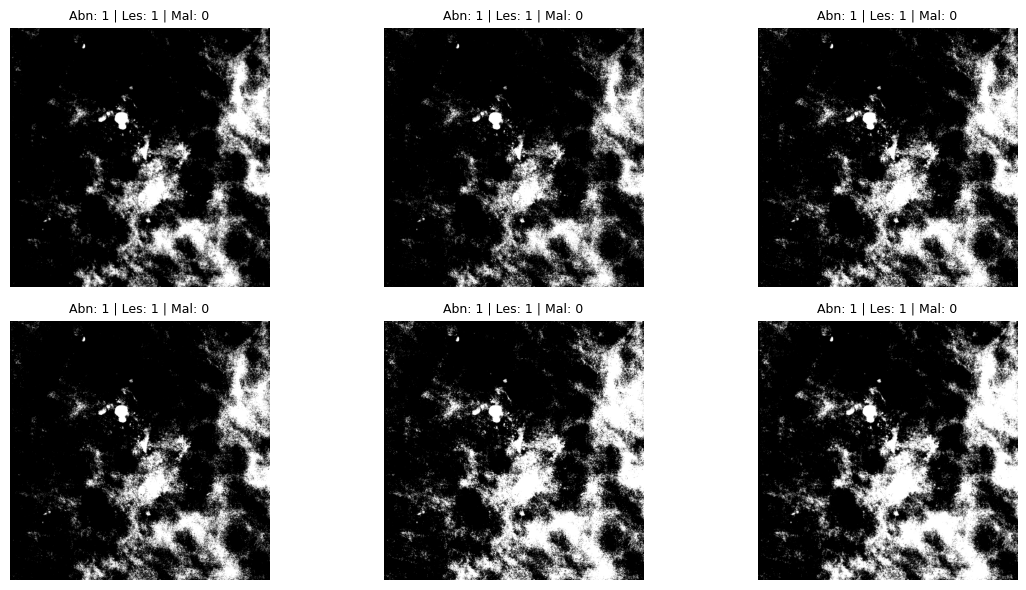

In [ ]:
inspect_dataset(train_ds_normalised, idx=2)

In [ ]:
#train_loader = DataLoader(train_ds_normalised, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False)
train_loader = DataLoader(train_ds_normalised, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds_normalised,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds_normalised,  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class FiLMBlock(nn.Module):
    def __init__(self, embedding_dim, feature_channels):
        super().__init__()
        # Generates channel-wise scaling (gamma) and shifting (beta) parameters
        self.get_gamma = nn.Linear(embedding_dim, feature_channels)
        self.get_beta = nn.Linear(embedding_dim, feature_channels)

    def forward(self, x, embedding):
        # x shape: [B, 512, 16, 16] for ResNet18 with 512x512 input
        gamma = self.get_gamma(embedding).unsqueeze(-1).unsqueeze(-1) # [B, 512, 1, 1]
        beta = self.get_beta(embedding).unsqueeze(-1).unsqueeze(-1)   # [B, 512, 1, 1]
        return ((1 + gamma) * x) + beta

class ResNet18UnifiedMammographyNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Shared ResNet-18 Core Backbone
        resnet18 = models.resnet18(weights="IMAGENET1K_V1")
        # Strip final global pool and fully-connected layers
        self.backbone = nn.Sequential(*list(resnet18.children())[:-2]) # Outputs: [B, 512, 16, 16]
        self.pool = nn.AdaptiveAvgPool2d((1, 1))                      # Collapses to [B, 512, 1, 1]

        # 2. Gate Modules (Adjusted channel inputs from 2048 down to 512)
        self.abn_embed = nn.Linear(512, 128)
        self.abn_classifier = nn.Linear(128, 2)
        self.film1 = FiLMBlock(embedding_dim=128, feature_channels=512)
        self.bn1 = nn.BatchNorm2d(512)

        self.les_embed = nn.Linear(512, 128)
        self.les_classifier = nn.Linear(128, 2) # [Mass, Calc]
        self.film2 = FiLMBlock(embedding_dim=128, feature_channels=512)
        self.bn2 = nn.BatchNorm2d(512)

        self.expert_dropout = nn.Dropout(0.4)

        # 3. Lesion Structural Experts (Outputs 3 logits: Normal, Benign, Malignant)
        self.mass_expert = nn.Sequential(nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, 3))
        self.calc_expert = nn.Sequential(nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, 3))

    def forward(self, x):
        # Input x shape: [B, 3, 512, 512]
        f0 = self.backbone(x)                 # Output shape: [B, 512, 16, 16]
        f0_pooled = self.pool(f0).flatten(1)  # Output shape: [B, 512]

        # Gate 1: Abnormality Extraction
        e_abn = torch.relu(self.abn_embed(f0_pooled))
        logits_abn = self.abn_classifier(e_abn)

        # Apply FiLM 1 to warp features based on abnormality traits
        f1 = self.film1(f0, e_abn)             # Output shape: [B, 512, 16, 16]
        f1 = self.bn1(f1)
        f1 = torch.relu(f1)
        f1_pooled = self.pool(f1).flatten(1)

        # Gate 2: Lesion Type Categorization
        e_les = torch.relu(self.les_embed(f1_pooled))
        logits_les = self.les_classifier(e_les)
        temperature = 2.0
        lesion_probs = torch.softmax(logits_les / temperature, dim=1)
        #lesion_probs = torch.softmax(logits_les, dim=1) # Shape: [B, 3]

        # Apply FiLM 2 to focus on lesion-specific structural features
        f2 = self.film2(f1, e_les)             # Output shape: [B, 512, 16, 16]
        f2 = self.bn2(f2)
        f2 = torch.relu(f2)
        f2_pooled = self.pool(f2).flatten(1)  # Output shape: [B, 512]
        f2_pooled = self.expert_dropout(f2_pooled)

        # Compute expert predictions using independent parameter paths
        out_mass = self.mass_expert(f2_pooled).unsqueeze(1) # Shape: [B, 1, 3]
        out_calc = self.calc_expert(f2_pooled).unsqueeze(1) # Shape: [B, 1, 3]

        # Merge individual expert evaluations
        all_expert_logits = torch.cat([out_mass, out_calc], dim=1) # Shape: [B, 2, 3]

        # Soft-route evaluations through matrix multiplication
        final_multiclass_logits = torch.bmm(lesion_probs.unsqueeze(1), all_expert_logits).squeeze(1) # Shape: [B, 3]

        return logits_abn, logits_les, final_multiclass_logits, lesion_probs


In [ ]:
import torch
from torchinfo import summary
# Assuming your network class definition is loaded above:
# from your_module import ResNet18UnifiedMammographyNet

# 1. Initialize your model
model = ResNet18UnifiedMammographyNet()

# 2. Define a dummy input matching your mammography image dimensions [Batch, Channels, Height, Width]
dummy_input = torch.randn(2, 3, 512, 512)

# 3. Generate and print the summary layout
# depth=3 allows us to peer inside your backbone and custom FiLM/Expert modules
model_stats = summary(model, input_data=dummy_input, depth=3, device="cpu")
print(model_stats)

Layer (type:depth-idx)                        Output Shape              Param #
ResNet18UnifiedMammographyNet                 [2, 2]                    --
├─Sequential: 1-1                             [2, 512, 16, 16]          --
│    └─Conv2d: 2-1                            [2, 64, 256, 256]         9,408
│    └─BatchNorm2d: 2-2                       [2, 64, 256, 256]         128
│    └─ReLU: 2-3                              [2, 64, 256, 256]         --
│    └─MaxPool2d: 2-4                         [2, 64, 128, 128]         --
│    └─Sequential: 2-5                        [2, 64, 128, 128]         --
│    │    └─BasicBlock: 3-1                   [2, 64, 128, 128]         73,984
│    │    └─BasicBlock: 3-2                   [2, 64, 128, 128]         73,984
│    └─Sequential: 2-6                        [2, 128, 64, 64]          --
│    │    └─BasicBlock: 3-3                   [2, 128, 64, 64]          230,144
│    │    └─BasicBlock: 3-4                   [2, 128, 64, 64]          295,42

In [ ]:
!pip install torchview graphviz

In [ ]:
import torch
from torchview import draw_graph
# Assuming your network class definition is loaded above

model = ResNet18UnifiedMammographyNet()
dummy_input = torch.randn(2, 3, 512, 512)

# Generate the architecture diagram graph
model_graph = draw_graph(
    model,
    input_data=dummy_input,
    graph_name="ResNet18UnifiedMammographyNet",
    depth=2,                         # Adjust depth to group/ungroup blocks
    expand_nested=True,              # Peek inside the sequential layers
    save_graph=True,                 # Saves a file to your local directory
    filename="mammography_net_arch"  # Saves as mammography_net_arch.png
)

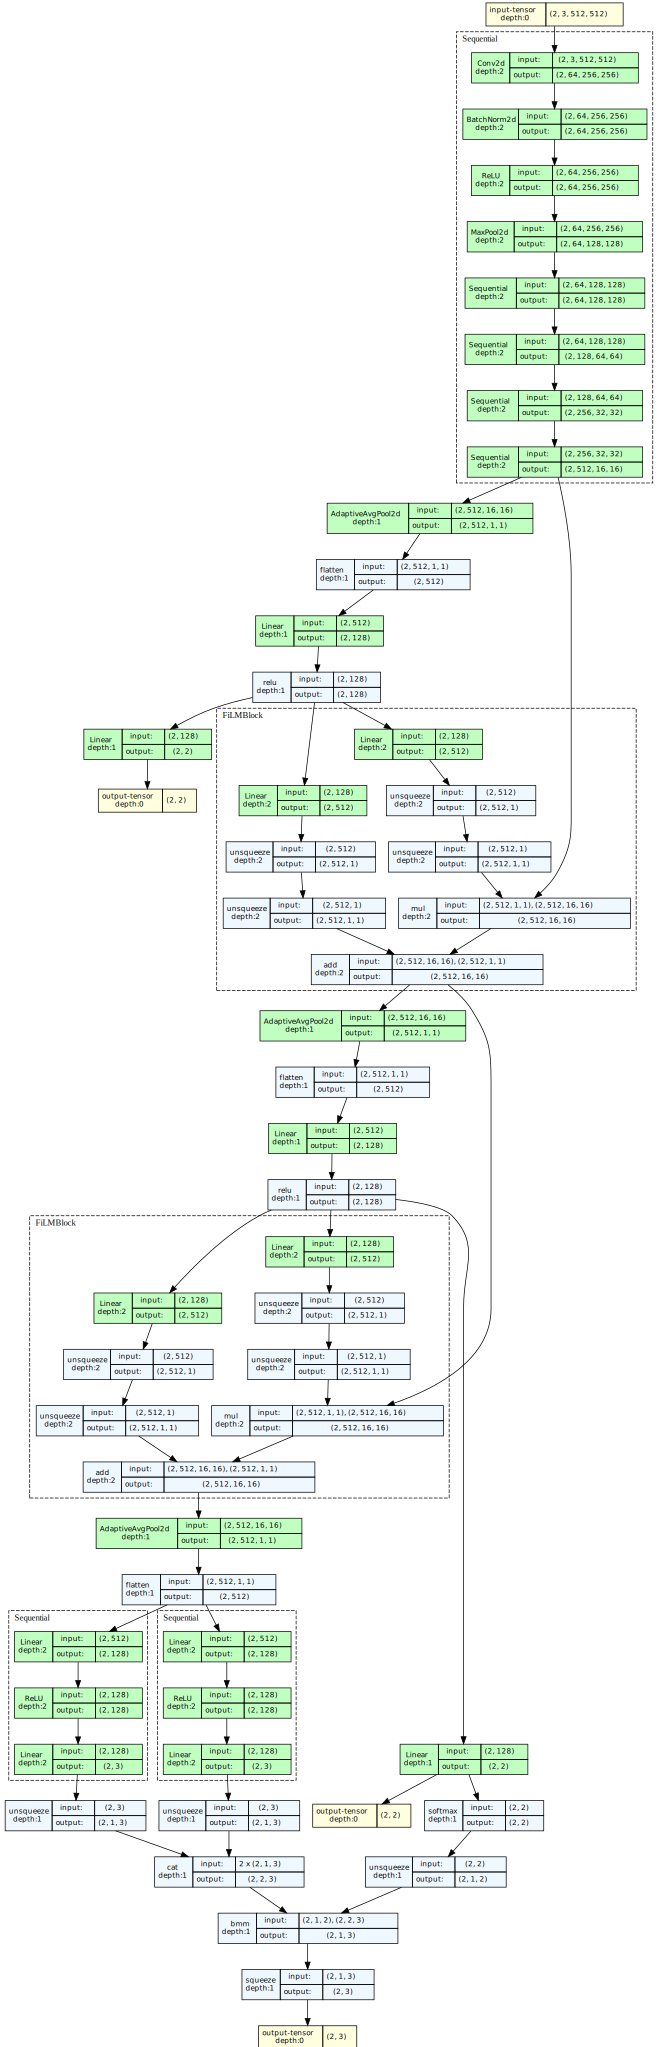

In [ ]:
model_graph.visual_graph

In [ ]:
# Calculate these based on your training data distribution: 1 / (count_of_class)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# 1. Extract your raw labels
all_labels = train_df["label"].values

# 2. Compute the standard linear balanced weights
raw_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

# 3. Apply a Square Root Smooth to prevent over-penalization
# This softens the impact of rare classes so they don't overpower the gradients
smoothed_weights = np.sqrt(raw_class_weights)

# 4. Normalize the weights so that the smallest weight equals 1.0
# This keeps your learning rate stable and predictable
final_weights = smoothed_weights / np.min(smoothed_weights)

# 5. Convert to PyTorch tensor for your CrossEntropyLoss
malignancy_weights = torch.tensor(final_weights, dtype=torch.float32).to(DEVICE)

# --- Quick Diagnostic Print ---
print("--- Automated Class Weight Summary ---")
for idx, cls in enumerate(np.unique(all_labels)):
    print(f"Class {cls} -> Raw sklearn weight: {raw_class_weights[idx]:.4f} | Smoothed & Normalized: {final_weights[idx]:.4f}")

--- Automated Class Weight Summary ---
Class 0 -> Raw sklearn weight: 4.5940 | Smoothed & Normalized: 2.7163
Class 1 -> Raw sklearn weight: 0.6226 | Smoothed & Normalized: 1.0000
Class 2 -> Raw sklearn weight: 0.8501 | Smoothed & Normalized: 1.1685


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import F1Score

# 1. Device Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 20
CHECKPOINT_FILE = "checkpoint_multihead.pt"
REPORT_INTERVAL = 1
patience = 3
ENTROPY_LAMBDA = 0.05

# Hyperparameter balancing weights for Multi-Task Loss
#alpha, beta, gamma = 0.5, 0.5, 1.0
alpha, beta, gamma = 0.2, 0.2, 1.0

model = ResNet18UnifiedMammographyNet().to(DEVICE)

# Double criteria configuration to support parallel batch masking safely
criterion_abn = nn.CrossEntropyLoss(reduction='mean')
criterion_malignancy = nn.CrossEntropyLoss(reduction='mean', weight=malignancy_weights)
criterion_masked = nn.CrossEntropyLoss(reduction='none')

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Multi-head diagnostic trackers
train_metric_abn = F1Score(task="multiclass", num_classes=2, average="macro").to(DEVICE)
val_metric_abn   = F1Score(task="multiclass", num_classes=2, average="macro").to(DEVICE)

train_metric_les = F1Score(task="multiclass", num_classes=2, average="macro").to(DEVICE)
val_metric_les   = F1Score(task="multiclass", num_classes=2, average="macro").to(DEVICE)

train_metric_mal = F1Score(task="multiclass", num_classes=3, average="macro").to(DEVICE)
val_metric_mal   = F1Score(task="multiclass", num_classes=3, average="macro").to(DEVICE)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
best_val_mal_f1 = 0.0
no_improve_count = 0

In [ ]:
history_train_abn, history_val_abn = [], []
history_train_les, history_val_les = [], []
history_train_mal, history_val_mal = [], []
history_train_abn_loss, history_val_abn_loss = [], []
history_train_les_loss, history_val_les_loss = [], []
history_train_mal_loss, history_val_mal_loss = [], []
history_train_entropy_loss, history_val_entropy_loss = [], []
history_train_loss, history_val_loss = [], []

for epoch in range(NUM_EPOCHS):
    # ------------------ TRAINING PHASE ------------------
    model.train()
    train_loss_sum = 0.0
    train_abn_loss_sum = 0.0
    train_les_loss_sum = 0.0
    train_mal_loss_sum = 0.0
    train_ent_loss_sum = 0.0

    train_metric_abn.reset()
    train_metric_les.reset()
    train_metric_mal.reset()

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images = xb.to(DEVICE)
        t_abn = yb['abn'].to(DEVICE)
        t_les = yb['les'].to(DEVICE)
        t_mal = yb['mal'].to(DEVICE)

        optimizer.zero_grad()
        out_abn, out_les, out_final, lesion_probs = model(images)

        # Loss 1 & 2: Calculated globally (All images have an Abnormality & Malignancy state)
        loss_abn = criterion_abn(out_abn, t_abn)
        train_metric_abn.update(out_abn, t_abn)

        loss_final = criterion_malignancy(out_final, t_mal)
        train_metric_mal.update(out_final, t_mal)

        # Loss 3: Masked strictly to evaluate only true lesions (Strips dummy labels)
        mask = (t_abn == 1)
        mask_sum = mask.sum()

        if mask_sum > 0:
            raw_les_loss = criterion_masked(out_les, t_les)
            loss_les = (raw_les_loss * mask.float()).sum() / mask_sum
            train_metric_les.update(out_les[mask], t_les[mask])
        else:
            loss_les = 0.0

        # Gating Entropy Regularization (Calculate safely using Categorical)
        dist = Categorical(probs=lesion_probs)
        # distribution entropy is -sum(p * log(p)), we negate it to maximize entropy
        loss_entropy = -dist.entropy().mean()

        # Backpropagation optimization
        total_loss = (alpha * loss_abn) + (beta * loss_les) + (gamma * loss_final) + (ENTROPY_LAMBDA * loss_entropy)
        total_loss.backward()
        optimizer.step()

        train_loss_sum += total_loss.item()
        train_abn_loss_sum += loss_abn.item()
        train_les_loss_sum += loss_les.item()
        train_mal_loss_sum += loss_final.item()
        train_ent_loss_sum += loss_entropy.item()

    avg_train_loss = train_loss_sum / len(train_loader)
    avg_train_abn_loss = train_abn_loss_sum / len(train_loader)
    avg_train_les_loss = train_les_loss_sum / len(train_loader)
    avg_train_mal_loss = train_mal_loss_sum / len(train_loader)
    avg_train_ent_loss = train_ent_loss_sum / len(train_loader)

    history_train_loss.append(avg_train_loss)
    history_train_abn_loss.append(avg_train_abn_loss)
    history_train_les_loss.append(avg_train_les_loss)
    history_train_mal_loss.append(avg_train_mal_loss)
    history_train_entropy_loss.append(avg_train_ent_loss)

    f1_train_abn = train_metric_abn.compute().item()
    f1_train_les = train_metric_les.compute().item()
    f1_train_mal = train_metric_mal.compute().item()

    history_train_abn.append(f1_train_abn)
    history_train_les.append(f1_train_les)
    history_train_mal.append(f1_train_mal)

    # ------------------ VALIDATION PHASE ------------------
    model.eval()
    val_loss_sum = 0.0
    val_abn_loss_sum = 0.0
    val_les_loss_sum = 0.0
    val_mal_loss_sum = 0.0
    val_ent_loss_sum = 0.0

    val_metric_abn.reset()
    val_metric_les.reset()
    val_metric_mal.reset()

    with torch.no_grad():
        for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            images = xb.to(DEVICE)
            t_abn, t_les, t_mal = yb['abn'].to(DEVICE), yb['les'].to(DEVICE), yb['mal'].to(DEVICE)

            out_abn, out_les, out_final, lesion_probs = model(images)

            l_abn = criterion_abn(out_abn, t_abn)
            val_metric_abn.update(out_abn, t_abn)

            l_final = criterion_malignancy(out_final, t_mal)
            val_metric_mal.update(out_final, t_mal)

            mask = (t_abn == 1)
            mask_sum = mask.sum()

            if mask_sum > 0:
                raw_l_les = criterion_masked(out_les, t_les)
                l_les = (raw_l_les * mask.float()).sum() / mask_sum
                val_metric_les.update(out_les[mask], t_les[mask])
            else:
                l_les = 0.0

            # Validate entropy distribution behavior
            v_dist = Categorical(probs=lesion_probs)
            l_entropy = -v_dist.entropy().mean()

            v_loss = (alpha * l_abn) + (beta * l_les) + (gamma * l_final) + (ENTROPY_LAMBDA * l_entropy)

            val_loss_sum += v_loss.item()
            val_abn_loss_sum += l_abn.item()
            val_les_loss_sum += l_les.item()
            val_mal_loss_sum += l_final.item()
            val_ent_loss_sum += l_entropy.item()

    avg_val_loss = val_loss_sum / len(val_loader)
    avg_val_abn_loss = val_abn_loss_sum / len(val_loader)
    avg_val_les_loss = val_les_loss_sum / len(val_loader)
    avg_val_mal_loss = val_mal_loss_sum / len(val_loader)
    avg_val_ent_loss = val_ent_loss_sum / len(val_loader)

    history_val_loss.append(avg_val_loss)
    history_val_abn_loss.append(avg_val_abn_loss)
    history_val_les_loss.append(avg_val_les_loss)
    history_val_mal_loss.append(avg_val_mal_loss)
    history_val_entropy_loss.append(avg_val_ent_loss)

    f1_val_abn = val_metric_abn.compute().item()
    f1_val_les = val_metric_les.compute().item()
    f1_val_mal = val_metric_mal.compute().item()

    history_val_abn.append(f1_val_abn)
    history_val_les.append(f1_val_les)
    history_val_mal.append(f1_val_mal)


    # ------------------ SCHEDULER & REGULARIZATION ------------------
    #scheduler.step(avg_val_loss)
    f1_error = 1.0 - f1_val_mal
    scheduler.step(f1_error)

    if f1_val_mal > best_val_mal_f1 + min_delta:
        best_val_mal_f1 = f1_val_mal
        no_improve_count = 0
        torch.save({"model_state": model.state_dict()}, CHECKPOINT_FILE)
        print(f"--> Saved Best Model! Val Malignancy Macro F1: {f1_val_mal:.4f}")
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"Early stopping triggered. No Malignancy F1 improvement for {patience} epochs.")
            break

    # ------------------ DIAGNOSTIC REPORTING ------------------
    if (epoch + 1) % REPORT_INTERVAL == 0:
        print(f"\n--- Epoch {epoch+1} Summary ---")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train Macro F1 -> Abn: {f1_train_abn:.3f}, Lesion: {f1_train_les:.3f}, Malignancy: {f1_train_mal:.3f}")
        print(f"Val Macro F1   -> Abn: {f1_val_abn:.3f}, Lesion: {f1_val_les:.3f}, Malignancy: {f1_val_mal:.3f}\n")

Epoch 1 [Val]: 100%|██████████| 9/9 [00:04<00:00,  1.90it/s]


--> Saved Best Model! Val Loss: 0.7961

--- Epoch 1 Summary ---
Train Loss: 1.0373 | Val Loss: 0.7961
Train Macro F1 -> Abn: 0.784, Lesion: 0.538, Malignancy: 0.503
Val Macro F1   -> Abn: 0.883, Lesion: 0.522, Malignancy: 0.563



Epoch 2 [Val]: 100%|██████████| 9/9 [00:04<00:00,  1.88it/s]


--> Saved Best Model! Val Loss: 0.6923

--- Epoch 2 Summary ---
Train Loss: 0.6874 | Val Loss: 0.6923
Train Macro F1 -> Abn: 0.899, Lesion: 0.713, Malignancy: 0.581
Val Macro F1   -> Abn: 0.896, Lesion: 0.745, Malignancy: 0.585



Epoch 3 [Val]: 100%|██████████| 9/9 [00:04<00:00,  1.89it/s]


...


--- Epoch 10 Summary ---
Train Loss: 0.0406 | Val Loss: 1.3367
Train Macro F1 -> Abn: 0.997, Lesion: 0.944, Malignancy: 0.998
Val Macro F1   -> Abn: 0.915, Lesion: 0.787, Malignancy: 0.658



Epoch 11 [Val]: 100%|██████████| 9/9 [00:04<00:00,  1.87it/s]



--- Epoch 11 Summary ---
Train Loss: 0.0208 | Val Loss: 1.3522
Train Macro F1 -> Abn: 0.998, Lesion: 0.977, Malignancy: 0.999
Val Macro F1   -> Abn: 0.930, Lesion: 0.779, Malignancy: 0.684



Epoch 12 [Val]: 100%|██████████| 9/9 [00:04<00:00,  1.83it/s]

Early stopping triggered due to validation stagnation.


In [ ]:
import gc
import torch

# 1. Clear out potential memory leaks from previous cell executions
try:
    del loss_abn, loss_les, loss_final, total_loss
except NameError:
    pass

# 2. Force Python and CUDA to completely empty their trash bins
gc.collect()
torch.cuda.empty_cache()

print("GPU Memory Cleared! Try running your loop again.")

GPU Memory Cleared! Try running your loop again.


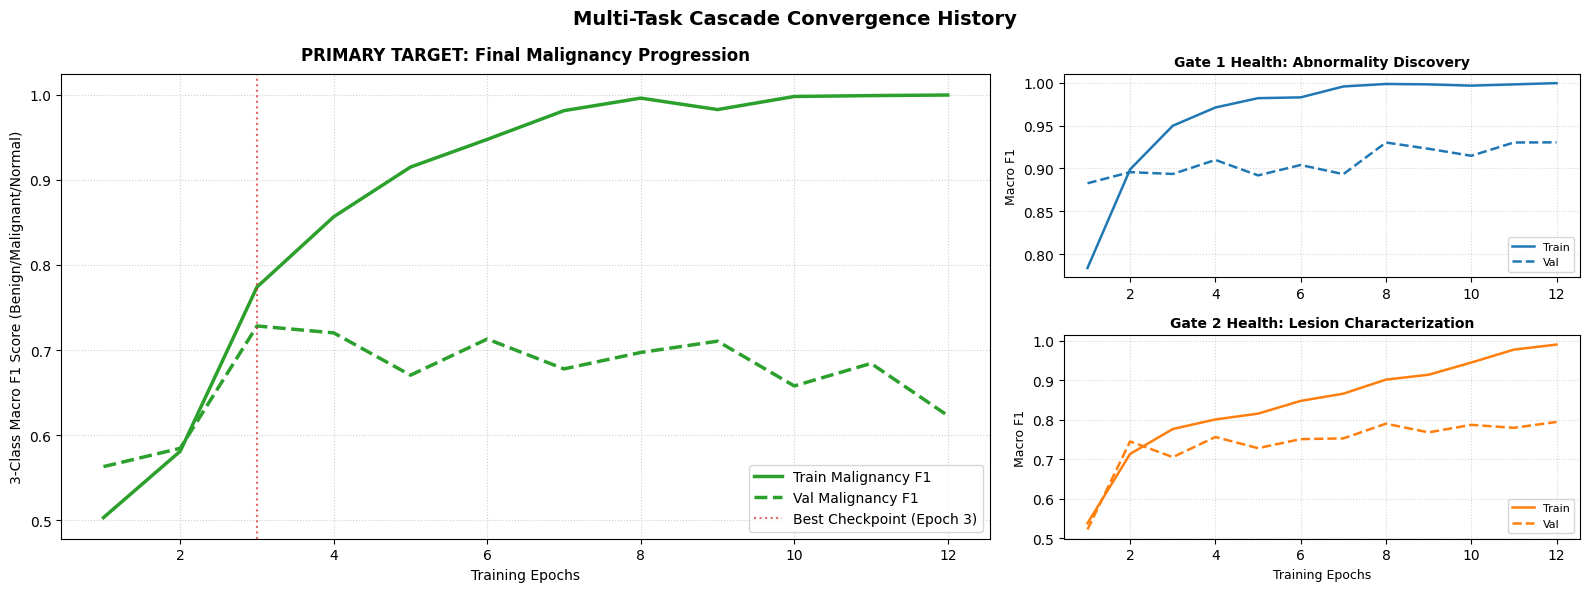

In [ ]:
import matplotlib.pyplot as plt

# Handle edge case if training was stopped early
epochs = range(1, len(history_train_mal) + 1)

# Set up canvas layout: 1 large diagnostic pane, 2 small helper subplots
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1])

# ==========================================
# 1. PRIMARY TARGET VIEW: MALIGNANCY FOCUS
# ==========================================
ax_main = fig.add_subplot(gs[:, 0])
ax_main.plot(epochs, history_train_mal, label='Train Malignancy F1', color='#2ca02c', linewidth=2.5)
ax_main.plot(epochs, history_val_mal, label='Val Malignancy F1', color='#2ca02c', linestyle='--', linewidth=2.5)

# Find and highlight the optimal model checkpoint epoch
if len(history_val_mal) > 0:
    best_epoch_idx = history_val_mal.index(max(history_val_mal))
    ax_main.axvline(x=best_epoch_idx + 1, color='#d62728', linestyle=':', alpha=0.7,
                    label=f'Best Checkpoint (Epoch {best_epoch_idx + 1})')

ax_main.set_title('PRIMARY TARGET: Final Malignancy Progression', fontsize=12, fontweight='bold', pad=10)
ax_main.set_xlabel('Training Epochs', fontsize=10)
ax_main.set_ylabel('3-Class Macro F1 Score (Benign/Malignant/Normal)', fontsize=10)
ax_main.legend(loc='lower right', frameon=True, shadow=False)
ax_main.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 2. SUB-GATE VIEW: ABNORMALITY
# ==========================================
ax_g1 = fig.add_subplot(gs[0, 1])
ax_g1.plot(epochs, history_train_abn, label='Train', color='#1f77b4', linewidth=1.8)
ax_g1.plot(epochs, history_val_abn, label='Val', color='#1f77b4', linestyle='--', linewidth=1.8)
ax_g1.set_title('Gate 1 Health: Abnormality Discovery', fontsize=10, fontweight='bold')
ax_g1.set_ylabel('Macro F1', fontsize=9)
ax_g1.grid(True, linestyle=':', alpha=0.5)
ax_g1.legend(loc='lower right', fontsize=8)

# ==========================================
# 3. SUB-GATE VIEW: LESION TYPE
# ==========================================
ax_g2 = fig.add_subplot(gs[1, 1])
ax_g2.plot(epochs, history_train_les, label='Train', color='#ff7f0e', linewidth=1.8)
ax_g2.plot(epochs, history_val_les, label='Val', color='#ff7f0e', linestyle='--', linewidth=1.8)
ax_g2.set_title('Gate 2 Health: Lesion Characterization', fontsize=10, fontweight='bold')
ax_g2.set_xlabel('Training Epochs', fontsize=9)
ax_g2.set_ylabel('Macro F1', fontsize=9)
ax_g2.grid(True, linestyle=':', alpha=0.5)
ax_g2.legend(loc='lower right', fontsize=8)

# Final formatting adjustments
plt.suptitle('Multi-Task Cascade Convergence History', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# Restore best model for evaluation
checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

# 1. Set up distinct multi-head test trackers
test_metric_abn = F1Score(task="multiclass", num_classes=2, average="macro").to(DEVICE)
test_metric_les = F1Score(task="multiclass", num_classes=2, average="macro").to(DEVICE)
test_metric_mal = F1Score(task="multiclass", num_classes=3, average="macro").to(DEVICE)

# Optional breakdown: Per-class F1 for Malignancy Focus (Benign, Malignant, Normal)
per_class_metric_mal = F1Score(task="multiclass", num_classes=3, average=None).to(DEVICE)

# Reset all trackers
test_loss_sum = 0.0
test_metric_abn.reset()
test_metric_les.reset()
test_metric_mal.reset()
per_class_metric_mal.reset()

print("Evaluating model on test dataset...")

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="[Test Evaluation]"):
        images = xb.to(DEVICE)

        # Unpack targets from batch dictionary
        t_abn = yb['abn'].to(DEVICE)
        t_les = yb['les'].to(DEVICE)
        t_mal = yb['mal'].to(DEVICE)

        # Forward Pass
        out_abn, out_les, out_final = model(images)

        # Loss 1 & 2: Global Heads (Abnormality & Malignancy)
        l_abn = criterion_abn(out_abn, t_abn)
        test_metric_abn.update(out_abn, t_abn)

        l_final = criterion_malignancy(out_final, t_mal)
        test_metric_mal.update(out_final, t_mal)
        per_class_metric_mal.update(out_final, t_mal) # Log breakdown simultaneously

        # Loss 3: Hierarchical Head (Lesion Type Matrix Selection)
        mask = (t_abn == 1)
        mask_sum = mask.sum()

        if mask_sum > 0:
            raw_l_les = criterion_masked(out_les, t_les)
            l_les = (raw_l_les * mask.float()).sum() / mask_sum

            # Explicit index selection to prevent structural dimension collapse
            valid_indices = torch.where(mask)[0]
            pred_filtered = torch.index_select(out_les, dim=0, index=valid_indices)
            target_filtered = torch.index_select(t_les, dim=0, index=valid_indices)

            test_metric_les.update(pred_filtered, target_filtered)
        else:
            l_les = 0.0

        # Calculate final balanced multi-task test loss
        v_loss = (alpha * l_abn) + (beta * l_les) + (gamma * l_final)
        test_loss_sum += v_loss.item()

# 2. Compute final aggregated metrics
avg_test_loss = test_loss_sum / max(1, len(test_loader))
f1_test_abn = test_metric_abn.compute().item()
f1_test_les = test_metric_les.compute().item()
f1_test_mal = test_metric_mal.compute().item()

# Compute per-class arrays for malignancy [Benign F1, Malignant F1, Normal F1]
f1_per_class_mal = per_class_metric_mal.compute().cpu().numpy()

# 3. Print Comprehensive Diagnostic Report
print("\n" + "="*50)
print("                  FINAL TEST METRICS")
print("="*50)
print(f"Average Multi-Task Test Loss: {avg_test_loss:.4f}")
print("-"*50)
print(f"Gate 1 -> Abnormality Macro F1: {f1_test_abn:.4f}")
print(f"Gate 2 -> Lesion Type Macro F1: {f1_test_les:.4f}")
print(f"Final  -> Malignancy  Macro F1: {f1_test_mal:.4f}")
print("-"*50)
print("Malignancy Per-Class Breakdown (Macro F1):")
print(f"  • Benign Tissue:     {f1_per_class_mal[0]:.4f}")
print(f"  • Malignant Tumors:  {f1_per_class_mal[1]:.4f}")
print(f"  • Normal Tissue:     {f1_per_class_mal[2]:.4f}")
print("="*50)

Evaluating model on test dataset...


[Test Evaluation]: 100%|██████████| 9/9 [00:05<00:00,  1.56it/s]


                  FINAL TEST METRICS
Average Multi-Task Test Loss: 0.7818
--------------------------------------------------
Gate 1 -> Abnormality Macro F1: 0.8971
Gate 2 -> Lesion Type Macro F1: 0.7823
Final  -> Malignancy  Macro F1: 0.5727
--------------------------------------------------
Malignancy Per-Class Breakdown (Macro F1):
  • Benign Tissue:     0.0000
  • Malignant Tumors:  0.8533
  • Normal Tissue:     0.8646


In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize Subplots (1 Row, 3 Columns for your 3 Gates)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs = range(1, len(history_train_abn) + 1)

# ---- Plot Gate 1: Abnormality ----
axes[0].plot(epochs, history_train_abn, label='Train Abn F1', color='tab:blue', linewidth=2)
axes[0].plot(epochs, history_val_abn, label='Val Abn F1', color='tab:blue', linestyle='--', linewidth=2)
axes[0].set_title('Gate 1: Abnormality Discovery')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Macro F1 Score')
axes[0].legend()
axes[0].grid(True)

# ---- Plot Gate 2: Lesion Type ----
axes[1].plot(epochs, history_train_les, label='Train Lesion F1', color='tab:orange', linewidth=2)
axes[1].plot(epochs, history_val_les, label='Val Lesion F1', color='tab:orange', linestyle='--', linewidth=2)
axes[1].set_title('Gate 2: Lesion Type Classification')
axes[1].set_xlabel('Epochs')
axes[1].grid(True)
axes[1].legend()

# ---- Plot Final Track: Malignancy ----
axes[2].plot(epochs, history_train_mal, label='Train Malignancy F1', color='tab:green', linewidth=2)
axes[2].plot(epochs, history_val_mal, label='Val Malignancy F1', color='tab:green', linestyle='--', linewidth=2)
axes[2].set_title('Final Proximity: Malignancy Focus')
axes[2].set_xlabel('Epochs')
axes[2].grid(True)
axes[2].legend()

plt.suptitle('Multi-Task Learning Performance Convergence', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()